# CentralValleySR - - - Complete End-to-End Analysis

This one notebook runs the **entire study start to finish on real data**:

1. **Baseline crop-specific NDVI** computed from real Sentinel-2 + USDA CDL (the time series the paper interprets).
2. **Real super-resolution training pairs** built from Sentinel-2 growing-season composites over crop pixels.
3. **One scale-aware super-resolution model** trained and evaluated against a bicubic baseline.
4. **Impact analysis**: does super-resolution recover NDVI better than bicubic, which is the actual research question!
5. **Manuscript-ready** tables, figures, metrics, and a provenance manifest.

#### What was broken before, and is fixed here:
- **The baseline NDVI had no real data source.** The old final notebook required `baseline_ndvi_all_crops.csv`, which nothing produced, so in strict mode it crashed. Here, **Part 3 computes that table from real Earth Engine data.**
- **The NDVI band order was wrong!** The old final notebook assumed `[Blue,Green,Red,NIR]` (`RED_IDX=2`), but the patches are saved `[Red,Green,Blue,NIR]`. That made every NDVI number `(NIR−Blue)/(NIR+Blue)` — meaningless. Band order is now defined **once** as `RED_IDX=0, NIR_IDX=3` and used everywhere.
- **No synthetic fallbacks.** Every "demo scene" path is removed; missing real data fails loudly instead of silently faking results.
- **One model, not two.** The redundant `SimpleSRNet` is dropped; a single scale-aware residual CNN is trained and analysed.
- **Checkpoint loading** uses `weights_only=False` so it works on newer PyTorch.

### How to run
Set your Earth Engine project in Part 0. On the **first run** the Earth-Engine steps (Parts 3–4) take a while; results are cached to disk, so **re-runs skip straight to training/analysis**. Set `REGENERATE_BASELINE` / `REGENERATE_PAIRS` to `True` only when you want to rebuild from Earth Engine!

Please ping Mentor if there are any issues or questions that arise!

#### What changed in this revision (train/val/test + evaluation credibility):
- **A real held-out test set.** Train/validation/test are now split by year
  (2018-2020 / 2021 / 2022), or by geographic block if a target crop turns out to be
  nearly absent from 2022 (Part 5c-5d). Only the test set is reported as "final results";
  validation is used solely for early stopping.
- **Per-patch metrics, not batch-mean metrics.** MAE/MSE/PSNR/SSIM/NDVI RMSE are computed
  for every test patch individually (`test_patch_metrics.csv`) and then summarized
  (mean/std/median/95% CI, paired model-vs-bicubic), instead of averaging one number per
  batch (which made the old result depend on batch size).
- **Crop-specific claims now have crop-specific evidence.** `sr_metrics_by_crop.csv` and
  `patch_counts_by_year_crop.csv` show exactly how many test patches back each crop's number,
  so the paper can't claim more than the data supports (e.g. for citrus).
- **Hydro-year wet/drought labels are derived, not hand-typed**, from real PRISM annual
  precipitation (`annual_precipitation_labels.csv`).
- **A wider data-infrastructure audit**: uniqueness of filenames/coordinates, finite/
  reflectance-range checks, band-order and LR=4x-area-average(HR) checks, and a
  train/val/test overlap check, all before the numbers are trusted.


# Part 0 — Environment, reproducibility, device, Earth Engine

In [ ]:
# Colab: run once. Local (conda/venv): install into your env and comment this out.
!pip -q install earthengine-api numpy pandas matplotlib scikit-image scipy torch torchvision

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os, sys, math, json, random, platform, io, time, urllib.request
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Optional extras (used if present, skipped cleanly if not)
try:
    from skimage.metrics import structural_similarity as ssim
    SKIMAGE_AVAILABLE = True
except Exception:
    SKIMAGE_AVAILABLE = False
try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# display() works in notebooks; define a no-op-safe fallback for plain Python
try:
    display
except NameError:
    from IPython.display import display

print("Python      :", sys.version.split()[0], "|", platform.machine())
print("PyTorch     :", torch.__version__)
print("CUDA avail  :", torch.cuda.is_available())
print("MPS avail   :", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)
print("scikit-image:", SKIMAGE_AVAILABLE, "| scipy:", SCIPY_AVAILABLE)

Python      : 3.12.13 | x86_64
PyTorch     : 2.11.0+cu128
CUDA avail  : True
MPS avail   : False
scikit-image: True | scipy: True


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device: CUDA (Colab) -> MPS (Apple Silicon) -> CPU
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
def choose_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")
device = choose_device()
try:
    _ = torch.ones(2, device=device)
except Exception as e:
    print("Device smoke test failed, falling back to CPU:", e)
    device = torch.device("cpu")
print("Using device:", device)

Using device: cuda


Earth Engine == Edit `EE_PROJECT` to your Earth-Engine-enabled Cloud project. Earth Engine is only needed when actually (re)building the baseline NDVI table or the SR pairs; if both are already cached on disk you can keep going even if auth fails.

In [ ]:
import ee

# ---- EDIT THIS to your Earth Engine project ----
EE_PROJECT = "bubbly-machine-481403-c5"

EE_READY = False
try:
    ee.Initialize(project=EE_PROJECT)
    EE_READY = True
    print("Earth Engine initialized with project:", EE_PROJECT)
except Exception:
    try:
        ee.Authenticate()
        ee.Initialize(project=EE_PROJECT)
        EE_READY = True
        print("Earth Engine initialized with project:", EE_PROJECT)
    except Exception as e:
        print("Earth Engine NOT initialized:", str(e)[:160])
        print("That's OK only if the baseline CSV and SR pairs are already cached on disk.")

Earth Engine initialized with project: bubbly-machine-481403-c5


# Part 1 — Global configuration

Everything downstream reads these values. The band order is fixed here once and must not be redefined elsewhere.

In [ ]:
# ---------- Paths ----------
PROJECT_ROOT  = Path(".").resolve()
PAIRS_DIR     = PROJECT_ROOT / "data_pairs" / "sr_pairs_x4"   # SR pair location (x4)
RESULTS_DIR   = PROJECT_ROOT / "results"
FIG_DIR       = PROJECT_ROOT / "figures" / "paper"
CHECKPOINT_DIR= PROJECT_ROOT / "checkpoints"
PAPER_DIR     = PROJECT_ROOT / "paper"
for d in [PAIRS_DIR, RESULTS_DIR, FIG_DIR, CHECKPOINT_DIR, PAPER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = PAIRS_DIR / "train_files.csv"
VAL_CSV   = PAIRS_DIR / "val_files.csv"
TEST_CSV  = PAIRS_DIR / "test_files.csv"
BASELINE_CSV = RESULTS_DIR / "baseline_ndvi_all_crops.csv"

# ---------- Study area / period ----------
S2_SR_ID  = "COPERNICUS/S2_SR_HARMONIZED"
CDL_ID    = "USDA/NASS/CDL"
AOI_BBOX  = [-122.0, 38.0, -121.0, 38.5]          # Northern Central Valley / Sacramento-Delta
YEARS     = [2018, 2019, 2020, 2021, 2022]
# Hydro-year labels (wet/drought) are DERIVED from real PRISM annual precipitation in
# Part 1b below -- not hand-typed. YEAR_LABELS is created there, from
# results/annual_precipitation_labels.csv.
CROP_CODES  = {"ALFALFA": 36, "ALMOND": 75, "CITRUS": 72, "GRAPES": 69}  # USDA CDL codes
CROP_CODE_LIST = list(CROP_CODES.values())

# ---------- Bands & NDVI indices (FIXED ONCE — do not redefine) ----------
SR_BANDS = ["B4", "B3", "B2", "B8"]   # Red, Green, Blue, NIR
RED_IDX  = 0                          # B4
NIR_IDX  = 3                          # B8

# ---------- Super-resolution settings ----------
SCALE           = 4
PATCH_SIZE_HR   = 128                 # divisible by SCALE
PATCH_SIZE_LR   = PATCH_SIZE_HR // SCALE
HR_SCALE_METERS = 10                  # S2 native res for these bands
CDL_SCALE       = 30                  # CDL native res
MIN_CROP_FRACTION = 0.3               # 0.0 = center-on-crop only; raise (e.g. 0.6) for purer patches

# ---------- Baseline NDVI extraction ----------
MAX_CLOUD         = 60
NDVI_REDUCE_SCALE = 60                # regional-mean NDVI is robust at coarser scale -> fast & safe

# ---------- Train / validation / test split ----------
# Primary strategy: chronological hold-out by acquisition year. This avoids the
# same-composite leakage risk described in Part 5 -- nearby/overlapping 1.28 km patches
# drawn from the same growing-season composite could otherwise show up in both train and
# a random validation/test split, letting the model "recognize" a field it already saw.
SPLIT_TRAIN_YEARS  = [2018, 2019, 2020]
SPLIT_VAL_YEAR     = 2021
SPLIT_TEST_YEAR    = 2022
# Fallback strategy (used automatically if a target crop is nearly absent from the test
# year, see Part 5c): assign whole geographic blocks -- not individual patches -- to
# train/val/test, so no block straddles a split and nearby/overlapping patches can't leak
# across splits either. This is never an unrestricted random per-patch split.
GEO_BLOCK_SIZE_DEG      = 0.02        # ~2.2 km blocks at this latitude, bigger than the 1.28 km patch
SPATIAL_SPLIT_FRACTIONS = {"train": 0.6, "val": 0.2, "test": 0.2}
MIN_TEST_CROP_COUNT     = 30          # a crop needs >= this many test patches ...
MIN_TEST_CROP_SHARE     = 0.05        # ... or >= this share of that crop's total patches,
                                       # else the chronological split falls back to spatial-block

# ---------- Run controls ----------
QUICK_TEST           = False          # True = small/fast (30 patches/yr). False = full dataset (100/yr).
NUM_PATCHES_PER_YEAR = 3000 # Increased for 15,000 SR pairs (3000 patches/year * 5 years).
MIN_TOTAL_PAIRS      = 15000 # Minimum total pairs for the new requirement.
MAX_ATTEMPTS_FACTOR  = 10 # Increased to allow more attempts for generating a larger number of patches.
VAL_FRACTION         = 0.15  # (kept for reference; the actual split is by year/block above, not this)

REGENERATE_BASELINE  = False          # True forces rebuilding baseline NDVI from Earth Engine
REGENERATE_PAIRS     = False          # True forces rebuilding SR pairs from Earth Engine
REGENERATE_MANIFEST_DETAILS = False   # True forces rebuilding manifest_details.csv (incl. EE crop-fraction/label lookups)
REGENERATE_PRECIP_LABELS    = False   # True forces rebuilding annual_precipitation_labels.csv from PRISM

assert PATCH_SIZE_HR % SCALE == 0, "PATCH_SIZE_HR must be divisible by SCALE"
AOI = ee.Geometry.Rectangle(AOI_BBOX) if EE_READY else None

print("Bands     :", SR_BANDS, "| RED_IDX", RED_IDX, "(B4) NIR_IDX", NIR_IDX, "(B8)")
print("Crops     :", CROP_CODES)
print("SR        : x{} | HR {} | LR {}".format(SCALE, PATCH_SIZE_HR, PATCH_SIZE_LR))
print("Run mode  :", "QUICK_TEST" if QUICK_TEST else "FULL")
print("Pairs dir :", PAIRS_DIR)


Bands     : ['B4', 'B3', 'B2', 'B8'] | RED_IDX 0 (B4) NIR_IDX 3 (B8)
Crops     : {'ALFALFA': 36, 'ALMOND': 75, 'CITRUS': 72, 'GRAPES': 69}
SR        : x4 | HR 128 | LR 32
Run mode  : FULL
Pairs dir : /content/data_pairs/sr_pairs_x4


In [ ]:
# Provenance manifest (records whether outputs come from real data)
run_manifest = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "project_root": str(PROJECT_ROOT),
    "band_order": SR_BANDS,
    "red_idx": RED_IDX, "nir_idx": NIR_IDX,
    "baseline_data_source": None,
    "sr_pair_data_source": None,
    "paper_ready": False,
    "notes": [],
}
def save_manifest():
    with open(RESULTS_DIR / "run_manifest.json", "w") as f:
        json.dump(run_manifest, f, indent=2, default=str)
save_manifest()
print("Manifest initialized.")

Manifest initialized.


## Part 1b — PRISM annual precipitation and hydrologic-year labels

`YEAR_LABELS` (wet vs. drought) is derived here from real PRISM monthly precipitation
(`OREGONSTATE/PRISM/AN81m`), summed to an annual total over the study AOI and compared to
the 2018-2022 multi-year mean -- instead of being typed in by hand. This feeds both the
baseline-NDVI wet/drought grouping in Part 3 and the manuscript text in Part 8.
Output: `results/annual_precipitation_labels.csv` with columns `year`,
`annual_precipitation_mm`, `multi_year_mean_mm`, `label`.


In [ ]:
PRECIP_LABELS_CSV = RESULTS_DIR / "annual_precipitation_labels.csv"

def prism_annual_precip_mm(year, region, scale_m=4000):
    """Real annual precipitation (mm) for `year`, averaged over `region`, from PRISM ANm."""
    start = f"{year}-01-01"; end = f"{year}-12-31"
    annual_total = (ee.ImageCollection("OREGONSTATE/PRISM/ANm")
                    .filterDate(start, end).select("ppt").sum())
    val = annual_total.reduceRegion(reducer=ee.Reducer.mean(), geometry=region,
                                    scale=scale_m, bestEffort=True, maxPixels=int(1e9)).get("ppt")
    return float(ee.Number(val).getInfo())

if PRECIP_LABELS_CSV.exists() and not REGENERATE_PRECIP_LABELS:
    precip_df = pd.read_csv(PRECIP_LABELS_CSV)
    run_manifest["year_labels_source"] = f"cached_csv:{PRECIP_LABELS_CSV}"
    print("Loaded cached PRISM precipitation labels:", PRECIP_LABELS_CSV)
else:
    if not EE_READY:
        raise RuntimeError("annual_precipitation_labels.csv must be built from Earth Engine (PRISM), "
                           "but EE is not initialized. Fix EE auth in Part 0, or provide a cached CSV.")
    print("Computing real annual precipitation from PRISM for", YEARS, "...")
    rows = [{"year": y, "annual_precipitation_mm": prism_annual_precip_mm(y, AOI)} for y in YEARS]
    precip_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
    multi_year_mean = float(precip_df["annual_precipitation_mm"].mean())
    precip_df["multi_year_mean_mm"] = multi_year_mean
    precip_df["label"] = np.where(precip_df["annual_precipitation_mm"] >= multi_year_mean, "wet", "drought")
    precip_df.to_csv(PRECIP_LABELS_CSV, index=False)
    run_manifest["year_labels_source"] = "earth_engine_real:PRISM/ANm"
    print("Saved real PRISM annual precipitation labels:", PRECIP_LABELS_CSV)

# YEAR_LABELS is now DERIVED from real data (not hand-typed).
YEAR_LABELS = dict(zip(precip_df["year"].astype(int), precip_df["label"]))
save_manifest()
display(precip_df)
print("YEAR_LABELS (derived from PRISM):", YEAR_LABELS)


Computing real annual precipitation from PRISM for [2018, 2019, 2020, 2021, 2022] ...
Saved real PRISM annual precipitation labels: /content/results/annual_precipitation_labels.csv


,year,annual_precipitation_mm,multi_year_mean_mm,label
0,2018,436.516405,384.82763,wet
1,2019,575.929485,384.82763,wet
2,2020,171.506592,384.82763,drought
3,2021,466.310333,384.82763,wet
4,2022,273.875335,384.82763,drought


YEAR_LABELS (derived from PRISM): {2018: 'wet', 2019: 'wet', 2020: 'drought', 2021: 'wet', 2022: 'drought'}


# Part 2 — Earth Engine helpers, which are shared by baseline NDVI and SR pairs

In [ ]:
def mask_s2_scl(img):
    """Cloud-mask Sentinel-2 SR using the SCL band (keep vegetation/soil/water/unclassified)."""
    scl = img.select("SCL")
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return img.updateMask(good)

def get_cdl_image(year):
    """USDA CDL image for a given year."""
    img = ee.ImageCollection(CDL_ID).filter(ee.Filter.calendarRange(year, year, "year")).first()
    return ee.Image(img)

def cdl_crop_band_name(cdl_img):
    """CDL band name varies by year; pick 'cropland'/'classification' or the first band."""
    bands = cdl_img.bandNames()
    return ee.String(ee.Algorithms.If(bands.contains("cropland"), "cropland",
                ee.Algorithms.If(bands.contains("classification"), "classification", bands.get(0))))

def cdl_is_crop(year, codes):
    """Binary layer: 1 where CDL is in `codes`, else 0."""
    cdl  = get_cdl_image(year)
    band = cdl_crop_band_name(cdl)
    return cdl.select([band]).remap(list(codes), [1]*len(codes), 0).rename("is_crop")

def seasonal_composite(year):
    """Cloud-masked growing-season median composite (SR bands), for SR-pair extraction."""
    start = f"{year}-06-01"; end = f"{year}-09-30"
    col = (ee.ImageCollection(S2_SR_ID)
           .filterBounds(AOI).filterDate(start, end)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .map(mask_s2_scl))
    return col.select(SR_BANDS).median()

print("Earth Engine helpers ready." if EE_READY else "Earth Engine helpers defined (EE not initialized).")

Earth Engine helpers ready.


# Part 3 — Baseline crop-specific NDVI (REAL Sentinel-2 + CDL)

For each crop and year we cloud-mask every Sentinel-2 scene, compute `NDVI = (B8 − B4)/(B8 + B4)` (a ratio, so the reflectance scaling cancels), mask to that crop's CDL pixels, and take the regional mean (producing a real NDVI time series). Years are labelled wet/drought per the study convention.

> **Caching:** if `baseline_ndvi_all_crops.csv` already exists and `REGENERATE_BASELINE=False`, we load it and skip Earth Engine.
> **AOI note:** citrus is uncommon in this northern AOI, so it may return few/no pixels; crops with insufficient data are reported as not analysable here rather than fabricated.

In [ ]:
def ndvi_timeseries_for_crop(year, crop_code, scale=NDVI_REDUCE_SCALE):
    """Real per-scene mean NDVI over one crop's CDL pixels for one year."""
    crop_mask = cdl_is_crop(year, [crop_code]).selfMask()   # 1 on this crop, masked elsewhere
    start = f"{year}-01-01"; end = f"{year}-12-31"
    col = (ee.ImageCollection(S2_SR_ID)
           .filterBounds(AOI).filterDate(start, end)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .map(mask_s2_scl))
    def add_ndvi(im):
        nir = im.select("B8"); red = im.select("B4")
        ndvi = nir.subtract(red).divide(nir.add(red).add(1e-6)).rename("NDVI")
        return im.addBands(ndvi).updateMask(crop_mask)
    col = col.map(add_ndvi)
    def reduce_one(im):
        v = im.select("NDVI").reduceRegion(
            reducer=ee.Reducer.mean(), geometry=AOI,
            scale=scale, bestEffort=True, maxPixels=int(1e9), tileScale=4
        ).get("NDVI")
        return ee.Feature(None, {"date": im.date().format("YYYY-MM-dd"), "ndvi_mean": v})
    fc = ee.FeatureCollection(col.map(reduce_one)).filter(ee.Filter.notNull(["ndvi_mean"]))
    feats = fc.getInfo()["features"]
    return [(f["properties"]["date"], f["properties"]["ndvi_mean"]) for f in feats]

In [ ]:
if BASELINE_CSV.exists() and not REGENERATE_BASELINE:
    baseline_df = pd.read_csv(BASELINE_CSV, parse_dates=["date"])
    run_manifest["baseline_data_source"] = f"cached_csv:{BASELINE_CSV}"
    print("Loaded cached baseline NDVI:", BASELINE_CSV, "| rows:", len(baseline_df))
else:
    if not EE_READY:
        raise RuntimeError("Baseline NDVI must be built from Earth Engine, but EE is not initialized. "
                           "Fix EE auth in Part 0, or provide a cached baseline_ndvi_all_crops.csv.")
    print("Building baseline NDVI from Earth Engine (this can take several minutes)...")
    rows = []
    for crop_name, code in CROP_CODES.items():
        crop_total = 0
        for year in YEARS:
            try:
                series = ndvi_timeseries_for_crop(year, code)
            except Exception as e:
                print(f"   {crop_name} {year}: EE error ({str(e)[:80]}) - skipped")
                continue
            for date_str, val in series:
                rows.append({"date": date_str, "year": year, "crop": crop_name,
                             "ndvi_mean": float(val), "label": YEAR_LABELS.get(year, "unknown")})
            crop_total += len(series)
        print(f"   {crop_name}: {crop_total} scene-observations across {len(YEARS)} years")
    baseline_df = pd.DataFrame(rows)
    if baseline_df.empty:
        raise ValueError("No baseline NDVI observations returned. Check AOI/crop codes/EE access.")
    baseline_df["date"] = pd.to_datetime(baseline_df["date"])
    baseline_df.to_csv(BASELINE_CSV, index=False)
    run_manifest["baseline_data_source"] = f"earth_engine_real:{S2_SR_ID}+{CDL_ID}"
    print("Saved baseline NDVI:", BASELINE_CSV, "| rows:", len(baseline_df))

save_manifest()
display(baseline_df.head())
print("Crops present:", sorted(baseline_df["crop"].unique()))

Building baseline NDVI from Earth Engine (this can take several minutes)...
   ALFALFA: 538 scene-observations across 5 years
   ALMOND: 537 scene-observations across 5 years
   CITRUS: 366 scene-observations across 5 years
   GRAPES: 538 scene-observations across 5 years
Saved baseline NDVI: /content/results/baseline_ndvi_all_crops.csv | rows: 1979


,date,year,crop,ndvi_mean,label
0,2018-01-20,2018,ALFALFA,0.615916,wet
1,2018-01-20,2018,ALFALFA,0.589594,wet
2,2018-01-25,2018,ALFALFA,0.518265,wet
3,2018-01-25,2018,ALFALFA,0.546258,wet
4,2018-02-09,2018,ALFALFA,0.659210,wet


Crops present: ['ALFALFA', 'ALMOND', 'CITRUS', 'GRAPES']


## Baseline NDVI summary (wet vs drought, with significance)

The summary quantifies the drought signal per crop. When SciPy is available we add a Welch's t-test (wet vs drought NDVI), giving a defensible p-value for the Results section.

In [ ]:
summary_rows = []
for crop, sub in baseline_df.groupby("crop"):
    wet = sub[sub["label"].str.lower().eq("wet")]["ndvi_mean"].dropna()
    dry = sub[sub["label"].str.lower().eq("drought")]["ndvi_mean"].dropna()
    wet_mean = wet.mean() if len(wet) else np.nan
    dry_mean = dry.mean() if len(dry) else np.nan
    diff = dry_mean - wet_mean
    pct = 100 * diff / wet_mean if (wet_mean and not np.isnan(wet_mean)) else np.nan
    if SCIPY_AVAILABLE and len(wet) > 1 and len(dry) > 1:
        _, pval = scipy_stats.ttest_ind(wet, dry, equal_var=False)
    else:
        pval = np.nan
    summary_rows.append({
        "crop": crop, "wet_mean_ndvi": wet_mean, "drought_mean_ndvi": dry_mean,
        "drought_minus_wet": diff, "percent_change": pct, "welch_p_value": pval,
        "n_wet": int(len(wet)), "n_drought": int(len(dry)),
    })
baseline_summary = pd.DataFrame(summary_rows).sort_values("crop").reset_index(drop=True)
baseline_summary.to_csv(RESULTS_DIR / "baseline_ndvi_summary.csv", index=False)
display(baseline_summary.round(4))

# crops with too little data to interpret honestly
weak = baseline_summary[(baseline_summary["n_wet"] < 3) | (baseline_summary["n_drought"] < 3)]["crop"].tolist()
if weak:
    print("NOTE: insufficient data in this AOI to interpret:", weak,
          "- report these as not analysable rather than drawing conclusions.")

,crop,wet_mean_ndvi,drought_mean_ndvi,drought_minus_wet,percent_change,welch_p_value,n_wet,n_drought
0,ALFALFA,0.5671,0.5540,-0.0131,-2.3133,0.0579,310,228
1,ALMOND,0.4781,0.4590,-0.0191,-3.9981,0.0041,309,228
2,CITRUS,0.5315,0.4387,-0.0928,-17.4657,0.0000,148,218
3,GRAPES,0.4292,0.3823,-0.0470,-10.9407,0.0000,310,228


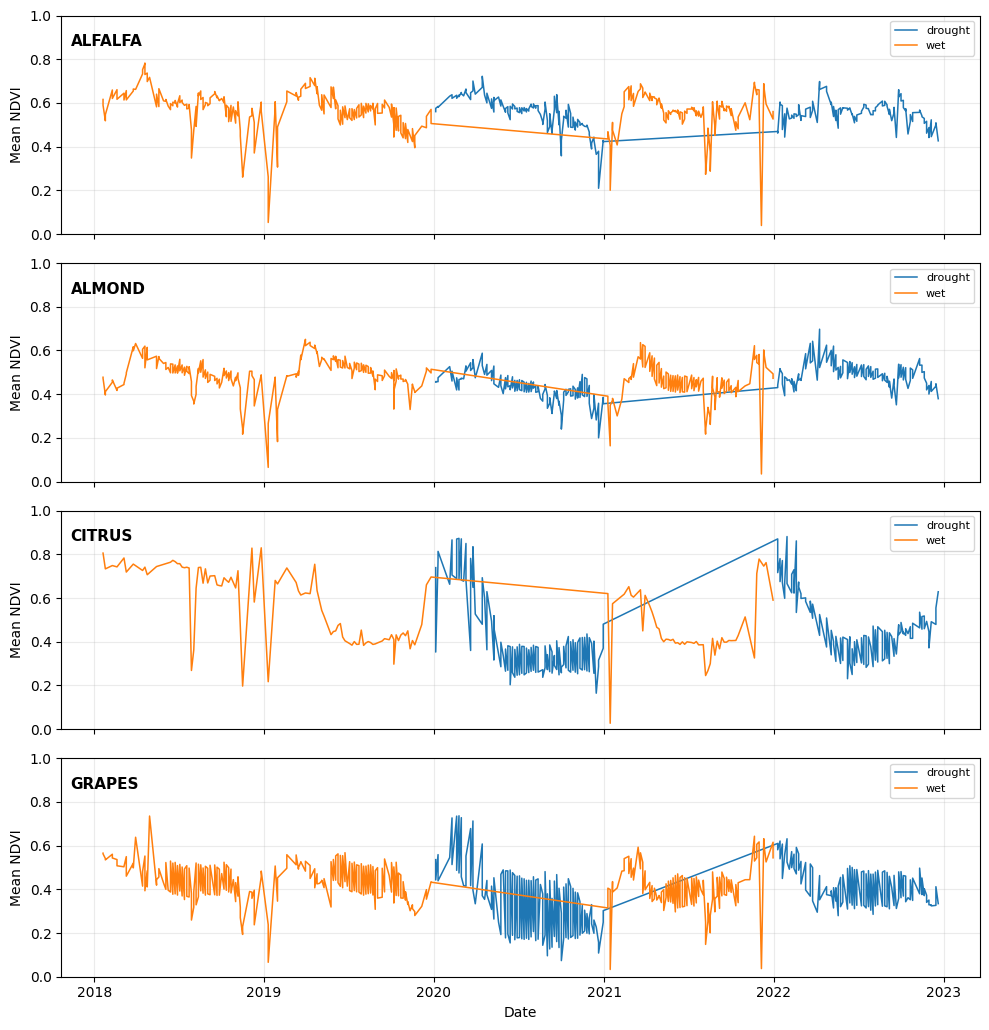

Saved: /content/figures/paper/figure_baseline_ndvi_by_crop.png


In [ ]:
def plot_baseline_ndvi(df, out_path):
    crops = sorted(df["crop"].unique())
    fig, axes = plt.subplots(len(crops), 1, figsize=(10, 2.6*len(crops)), sharex=True)
    if len(crops) == 1:
        axes = [axes]
    for ax, crop in zip(axes, crops):
        sub = df[df["crop"] == crop].sort_values("date")
        for label, grp in sub.groupby("label"):
            ax.plot(grp["date"], grp["ndvi_mean"], label=label, linewidth=1.1)
        ax.set_ylabel("Mean NDVI"); ax.set_ylim(0, 1)
        ax.text(0.01, 0.86, crop, transform=ax.transAxes, fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.25); ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Date"); fig.tight_layout()
    fig.savefig(out_path, dpi=250, bbox_inches="tight"); plt.show()

baseline_fig = FIG_DIR / "figure_baseline_ndvi_by_crop.png"
plot_baseline_ndvi(baseline_df, baseline_fig)
print("Saved:", baseline_fig)

# Part 4 — Real SR training pairs (Sentinel-2 over crop pixels)

Builds LR/HR patch pairs from real growing-season composites, sampled on target-crop pixels, saved as `lr`/`hr` arrays (band order `[B4,B3,B2,B8]`) in `data_pairs/sr_pairs_x4/`. The LR is a real area-average degradation of the real HR — no synthetic noise.

> **Caching:** if pairs already exist and `REGENERATE_PAIRS=False`, generation is skipped. Set `REGENERATE_PAIRS=True` (or `QUICK_TEST=False` for more data) to rebuild.

In [ ]:
# ---- pure-Python helpers for pair building ----
def structured_npy_to_hwc(arr, bands):
    return np.stack([arr[b].astype(np.float32) for b in bands], axis=-1)

def to_reflectance(hr_raw):
    return np.clip(hr_raw.astype(np.float32) / 10000.0, 0.0, 1.0)

def downsample_area_exact(hr, scale):
    H, W, C = hr.shape
    assert H % scale == 0 and W % scale == 0
    return hr.reshape(H//scale, scale, W//scale, scale, C).mean(axis=(1, 3)).astype(np.float32)

def is_valid_patch(hr_raw):
    if not np.isfinite(hr_raw).all():
        return False
    if float((hr_raw == 0).all(axis=-1).mean()) > 0.05:
        return False
    if float(hr_raw.std()) < 1e-6:
        return False
    return True

def download_hr_patch(image, lon, lat, size_px, scale_m, bands):
    half_m = (size_px * scale_m) / 2.0
    region = ee.Geometry.Point([lon, lat]).buffer(half_m).bounds()
    try:
        url = image.getDownloadURL({"bands": bands, "region": region,
                                    "dimensions": f"{size_px}x{size_px}", "format": "NPY"})
        raw = urllib.request.urlopen(url, timeout=120).read()
        return structured_npy_to_hwc(np.load(io.BytesIO(raw)), bands)
    except Exception as e:
        print("   download failed:", str(e)[:100]); return None

def crop_candidates(year, n, seed):
    """Random points on target-crop pixels; optional crop-purity filter on the patch window."""
    is_crop = cdl_is_crop(year, CROP_CODE_LIST)
    # Increased tileScale to help with Earth Engine internal processing limits for large samples.
    pts = is_crop.stratifiedSample(numPoints=0, classBand="is_crop", region=AOI, scale=CDL_SCALE,
                                   classValues=[1], classPoints=[n], seed=seed, tileScale=16, geometries=True)
    if MIN_CROP_FRACTION <= 0:
        feats = pts.getInfo()["features"]
        return [(f["geometry"]["coordinates"][0], f["geometry"]["coordinates"][1]) for f in feats]
    half_m = (PATCH_SIZE_HR * HR_SCALE_METERS) / 2.0
    def add_frac(feat):
        win = feat.geometry().buffer(half_m).bounds()
        # Increased tileScale here as well.
        frac = is_crop.reduceRegion(reducer=ee.Reducer.mean(), geometry=win, scale=CDL_SCALE,
                                    maxPixels=int(1e8), tileScale=16).get("is_crop")
        return feat.set("crop_frac", frac)
    feats = pts.map(add_frac).getInfo()["features"]
    out = []
    for f in feats:
        fr = f["properties"].get("crop_frac")
        if fr is not None and fr >= MIN_CROP_FRACTION:
            out.append((f["geometry"]["coordinates"][0], f["geometry"]["coordinates"][1]))
    return out

print("Pair-building helpers ready.")

Pair-building helpers ready.


In [ ]:
import shutil
from google.colab import files

existing = sorted(PAIRS_DIR.glob("*.npz"))
have_enough = len(existing) >= MIN_TOTAL_PAIRS

if have_enough and not REGENERATE_PAIRS:
    run_manifest["sr_pair_data_source"] = f"cached_real_npz:{PAIRS_DIR} ({len(existing)} files)"
    print(f"Found {len(existing)} cached pairs in {PAIRS_DIR} - skipping generation.")
else:
    if not EE_READY:
        raise RuntimeError("SR pairs must be built from Earth Engine, but EE is not initialized. "
                           "Fix EE auth in Part 0, or provide cached pairs in data_pairs/sr_pairs_x4/")
    # fresh start so the folder holds only real pairs from this run
    for f in PAIRS_DIR.glob("*.npz"):
        f.unlink()
    print("Generating REAL SR pairs from Earth Engine...")
    manifest_files = []
    last_download_count = 0 # Initialize a counter for downloads

    for year in YEARS:
        print(f"\n=== Year {year} ===")
        composite = seasonal_composite(year)
        saved_for_year = 0
        attempt_seed_offset = 0
        MAX_CANDIDATES_PER_EE_CALL = 4500 # Max features to request from EE at once to avoid accumulation limits
        total_candidates_sampled_for_year = 0

        while saved_for_year < NUM_PATCHES_PER_YEAR and \
              total_candidates_sampled_for_year < (NUM_PATCHES_PER_YEAR * MAX_ATTEMPTS_FACTOR):

            # Request candidates in batches
            num_to_request_in_batch = min(MAX_CANDIDATES_PER_EE_CALL,
                                           (NUM_PATCHES_PER_YEAR * MAX_ATTEMPTS_FACTOR) - total_candidates_sampled_for_year)

            if num_to_request_in_batch <= 0:
                break # Already sampled enough or reached max attempts

            cands_batch = crop_candidates(year, num_to_request_in_batch, seed=SEED + year + attempt_seed_offset)
            attempt_seed_offset += 1
            total_candidates_sampled_for_year += len(cands_batch)

            if not cands_batch:
                print(f"   No more candidate points found in this batch for year {year}. Total saved: {saved_for_year}/{NUM_PATCHES_PER_YEAR}")
                break

            print(f"   Sampled {len(cands_batch)} candidate crop points in batch for year {year}. Total sampled: {total_candidates_sampled_for_year}")

            for lon, lat in cands_batch:
                if saved_for_year >= NUM_PATCHES_PER_YEAR:
                    break

                hr_raw = download_hr_patch(composite, lon, lat, PATCH_SIZE_HR, HR_SCALE_METERS, SR_BANDS)
                if hr_raw is None or hr_raw.shape != (PATCH_SIZE_HR, PATCH_SIZE_HR, len(SR_BANDS)):
                    continue
                if not is_valid_patch(hr_raw):
                    continue
                hr = to_reflectance(hr_raw)
                lr = downsample_area_exact(hr, SCALE)
                fname = f"S2_{year}_{lon:.5f}_{lat:.5f}.npz".replace("-", "m")
                np.savez_compressed(PAIRS_DIR / fname, lr=lr, hr=hr)
                manifest_files.append(fname); saved_for_year += 1
                if saved_for_year % 10 == 0:
                    print(f"   saved {saved_for_year}/{NUM_PATCHES_PER_YEAR} for year {year}")
                time.sleep(0.05)

                # Check if it's time to download
                if (len(manifest_files) - last_download_count) >= 3000:
                    zip_filename = f'sr_pairs_x4_{len(manifest_files)}.zip'
                    print(f"\nDownloading {len(manifest_files)} pairs to {zip_filename}...")
                    # Create a temporary zip archive of the directory
                    archive_base_name = f'sr_pairs_x4_checkpoint_{len(manifest_files)}'
                    shutil.make_archive(archive_base_name, 'zip', PAIRS_DIR)
                    # Download the created zip file
                    files.download(f'{archive_base_name}.zip')
                    last_download_count = len(manifest_files)
                    print(f"Download complete for {len(manifest_files)} pairs.")


        print(f"   -> {saved_for_year} patches for {year} (target: {NUM_PATCHES_PER_YEAR})")

    assert len(manifest_files) >= MIN_TOTAL_PAIRS, (
        f"Only saved {len(manifest_files)} pairs (< {MIN_TOTAL_PAIRS}). "
        f"Lower MIN_CROP_FRACTION, raise MAX_ATTEMPTS_FACTOR, or check EE/AOI/season.")
    run_manifest["sr_pair_data_source"] = f"earth_engine_real:{S2_SR_ID}"
    print("\nTotal real pairs:", len(manifest_files))

    # Final download for any remaining pairs if there are new ones since the last checkpoint
    if len(manifest_files) > last_download_count:
        zip_filename = f'sr_pairs_x4_final_{len(manifest_files)}.zip'
        print(f"\nDownloading final {len(manifest_files) - last_download_count} pairs to {zip_filename}...")
        archive_base_name = f'sr_pairs_x4_final'
        shutil.make_archive(archive_base_name, 'zip', PAIRS_DIR)
        files.download(f'{archive_base_name}.zip')
        print(f"Final download complete for {len(manifest_files)} pairs.")

save_manifest()


Generating REAL SR pairs from Earth Engine...

=== Year 2018 ===
   Sampled 3627 candidate crop points in batch for year 2018. Total sampled: 3627
   saved 10/3000 for year 2018
   saved 20/3000 for year 2018
   saved 30/3000 for year 2018
   saved 40/3000 for year 2018
   saved 50/3000 for year 2018
   saved 60/3000 for year 2018
   saved 70/3000 for year 2018
   saved 80/3000 for year 2018
   saved 90/3000 for year 2018
   saved 100/3000 for year 2018
   saved 110/3000 for year 2018
   saved 120/3000 for year 2018
   saved 130/3000 for year 2018
   saved 140/3000 for year 2018
   saved 150/3000 for year 2018
   saved 160/3000 for year 2018
   saved 170/3000 for year 2018
   saved 180/3000 for year 2018
   saved 190/3000 for year 2018
   saved 200/3000 for year 2018
   saved 210/3000 for year 2018
   saved 220/3000 for year 2018
   saved 230/3000 for year 2018
   saved 240/3000 for year 2018
   saved 250/3000 for year 2018
   saved 260/3000 for year 2018
   saved 270/3000 for year 201

   saved 1320/3000 for year 2018
   saved 1330/3000 for year 2018
   saved 1340/3000 for year 2018
   saved 1350/3000 for year 2018
   saved 1360/3000 for year 2018
   saved 1370/3000 for year 2018
   saved 1380/3000 for year 2018
   saved 1390/3000 for year 2018
   saved 1400/3000 for year 2018
   saved 1410/3000 for year 2018
   saved 1420/3000 for year 2018
   saved 1430/3000 for year 2018
   saved 1440/3000 for year 2018
   saved 1450/3000 for year 2018
   saved 1460/3000 for year 2018
   saved 1470/3000 for year 2018
   saved 1480/3000 for year 2018
   saved 1490/3000 for year 2018
   saved 1500/3000 for year 2018
   saved 1510/3000 for year 2018
   saved 1520/3000 for year 2018
   saved 1530/3000 for year 2018
   saved 1540/3000 for year 2018
   saved 1550/3000 for year 2018
   saved 1560/3000 for year 2018
   saved 1570/3000 for year 2018
   saved 1580/3000 for year 2018
   saved 1590/3000 for year 2018
   saved 1600/3000 for year 2018
   saved 1610/3000 for year 2018
   saved 1

   saved 2700/3000 for year 2018
   saved 2710/3000 for year 2018
   saved 2720/3000 for year 2018
   saved 2730/3000 for year 2018
   saved 2740/3000 for year 2018
   saved 2750/3000 for year 2018
   saved 2760/3000 for year 2018
   saved 2770/3000 for year 2018
   saved 2780/3000 for year 2018
   saved 2790/3000 for year 2018
   saved 2800/3000 for year 2018
   saved 2810/3000 for year 2018
   saved 2820/3000 for year 2018
   saved 2830/3000 for year 2018
   saved 2840/3000 for year 2018
   saved 2850/3000 for year 2018
   saved 2860/3000 for year 2018
   saved 2870/3000 for year 2018
   saved 2880/3000 for year 2018
   saved 2890/3000 for year 2018
   saved 2900/3000 for year 2018
   saved 2910/3000 for year 2018
   saved 2920/3000 for year 2018
   saved 2930/3000 for year 2018
   saved 2940/3000 for year 2018
   saved 2950/3000 for year 2018
   saved 2960/3000 for year 2018
   saved 2970/3000 for year 2018
   saved 2980/3000 for year 2018
   saved 2990/3000 for year 2018
   saved 3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

   saved 1200/3000 for year 2022
   saved 1210/3000 for year 2022
   saved 1220/3000 for year 2022
   saved 1230/3000 for year 2022
   saved 1240/3000 for year 2022
   saved 1250/3000 for year 2022
   download failed: HTTP Error 503: Service Unavailable
   saved 1260/3000 for year 2022
   saved 1270/3000 for year 2022
   saved 1280/3000 for year 2022
   saved 1290/3000 for year 2022
   saved 1300/3000 for year 2022
   saved 1310/3000 for year 2022
   saved 1320/3000 for year 2022
   saved 1330/3000 for year 2022
   saved 1340/3000 for year 2022
   saved 1350/3000 for year 2022
   saved 1360/3000 for year 2022
   saved 1370/3000 for year 2022
   saved 1380/3000 for year 2022
   saved 1390/3000 for year 2022
   saved 1400/3000 for year 2022
   saved 1410/3000 for year 2022
   saved 1420/3000 for year 2022
   saved 1430/3000 for year 2022
   saved 1440/3000 for year 2022
   saved 1450/3000 for year 2022
   saved 1460/3000 for year 2022
   saved 1470/3000 for year 2022
   saved 1480/3000 f

   saved 2230/3000 for year 2022
   saved 2240/3000 for year 2022
   saved 2250/3000 for year 2022
   saved 2260/3000 for year 2022
   saved 2270/3000 for year 2022
   saved 2280/3000 for year 2022
   saved 2290/3000 for year 2022
   saved 2300/3000 for year 2022
   saved 2310/3000 for year 2022
   saved 2320/3000 for year 2022
   saved 2330/3000 for year 2022
   saved 2340/3000 for year 2022
   saved 2350/3000 for year 2022
   saved 2360/3000 for year 2022
   saved 2370/3000 for year 2022
   saved 2380/3000 for year 2022
   saved 2390/3000 for year 2022
   saved 2400/3000 for year 2022
   saved 2410/3000 for year 2022
   saved 2420/3000 for year 2022
   saved 2430/3000 for year 2022
   saved 2440/3000 for year 2022
   saved 2450/3000 for year 2022
   saved 2460/3000 for year 2022
   saved 2470/3000 for year 2022
   saved 2480/3000 for year 2022
   saved 2490/3000 for year 2022
   saved 2500/3000 for year 2022
   saved 2510/3000 for year 2022
   saved 2520/3000 for year 2022
   saved 2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete for 15000 pairs.
   -> 3000 patches for 2022 (target: 3000)

Total real pairs: 15000


# Part 5 — Load pairs, audit shapes, detect scale, build the train/val/test split

The scale factor and channel count are **detected from the actual files** (not
hard-coded). The data-infrastructure audit below checks far more than dimensions: unique
filenames/coordinates, missing/non-finite values, reflectance range, 4-band order, and
LR == 4x area-average(HR) within tolerance. The per-patch provenance manifest
(`manifest_details.csv`, Part 5b) is built *before* the split so the split decision itself
(Part 5c) can be based on real per-year, per-crop counts -- not assumed. The split
(Part 5d) is either chronological (train=2018-2020, val=2021, test=2022) or, if a target
crop is nearly absent from 2022, a grouped spatial-block split. Either way it is never an
unrestricted random per-patch split, and train/val/test filenames are checked for overlap.


In [ ]:
!cp /content/drive/MyDrive/sr_pairs_x4_checkpoint_15000.zip /content/
!unzip -q /content/sr_pairs_x4_checkpoint_15000.zip -d /content/data_pairs/sr_pairs_x4

In [ ]:
import re

pair_files = sorted(PAIRS_DIR.glob("*.npz"))
assert len(pair_files) > 0, f"No .npz pairs in {PAIRS_DIR}. Run Part 4."

# file names are written as f"S2_{year}_{lon:.5f}_{lat:.5f}.npz".replace("-", "m")
FNAME_RE = re.compile(r"^S2_(\d+)_(m?[\d.]+)_(m?[\d.]+)\.npz$")

def parse_pair_filename(fname):
    """Recover (year, lon, lat) from the pair-file naming convention; None,None,None if it doesn't match."""
    m = FNAME_RE.match(fname)
    if not m:
        return None, None, None
    def _num(tok):
        return -float(tok[1:]) if tok.startswith("m") else float(tok)
    return int(m.group(1)), _num(m.group(2)), _num(m.group(3))

def read_pair(path):
    d = np.load(path)
    return d["lr"].astype(np.float32), d["hr"].astype(np.float32)

# --- extended data-infrastructure audit ---
# Checks here: unique filenames/coordinates, missing/non-finite values, reflectance range,
# 4-band order (plausibility), LR == 4x area-average of HR (within tolerance), duplicate
# coordinates, and year counts (from filenames). Crop-fraction and crop/year-count checks
# that require the CDL lookup run later in Part 5c, once manifest_details_df exists.
audit_rows, valid_files = [], []
seen_coords = {}
LR_HR_ATOL = 1e-4  # numerical tolerance for LR == 4x area-average(HR)

for p in pair_files[:min(len(pair_files), 15000)]:
    fname = p.name
    year, lon, lat = parse_pair_filename(fname)
    row = {"file": fname, "year": year, "longitude": lon, "latitude": lat}
    try:
        lr, hr = read_pair(p)
        lh, lw, lc = lr.shape; hh, hw, hc = hr.shape
        sh, sw = hh / lh, hw / lw
        shape_ok = lr.ndim == 3 and hr.ndim == 3 and abs(sh - sw) < 1e-6 and lc == hc

        finite_ok = bool(np.isfinite(lr).all() and np.isfinite(hr).all())
        n_nonfinite = int((~np.isfinite(hr)).sum() + (~np.isfinite(lr)).sum())

        reflect_ok = bool((hr.min() >= -1e-6) and (hr.max() <= 1.0 + 1e-6) and
                          (lr.min() >= -1e-6) and (lr.max() <= 1.0 + 1e-6))

        bands_ok = (hc == len(SR_BANDS)) and (lc == len(SR_BANDS))
        # proxy for correct band order: NIR (index NIR_IDX) should on average read higher
        # reflectance than RED (index RED_IDX) over vegetated crop pixels
        band_order_plausible = bool(hr[..., NIR_IDX].mean() > hr[..., RED_IDX].mean()) if bands_ok else False

        if finite_ok and shape_ok:
            lr_expected = downsample_area_exact(hr, int(round(sh)))
            lr_match = bool(np.allclose(lr, lr_expected, atol=LR_HR_ATOL))
            lr_max_abs_err = float(np.max(np.abs(lr - lr_expected)))
        else:
            lr_match = False
            lr_max_abs_err = np.nan

        valid = shape_ok and finite_ok and reflect_ok and bands_ok
        row.update({
            "lr_shape": str(lr.shape), "hr_shape": str(hr.shape), "scale_h": sh, "channels": hc,
            "shape_ok": shape_ok, "finite_ok": finite_ok, "n_nonfinite": n_nonfinite,
            "reflectance_ok": reflect_ok, "hr_min": float(hr.min()), "hr_max": float(hr.max()),
            "bands_ok": bands_ok, "band_order_plausible": band_order_plausible,
            "lr_matches_4x_avg_hr": lr_match, "lr_max_abs_err_vs_4x_avg": lr_max_abs_err,
            "valid": bool(valid),
        })
        if valid:
            valid_files.append(fname)
    except Exception as e:
        row.update({"error": str(e), "valid": False})
    audit_rows.append(row)

    if lon is not None and lat is not None:
        seen_coords.setdefault((round(lon, 5), round(lat, 5)), []).append(fname)

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(RESULTS_DIR / "data_audit.csv", index=False)
assert valid_files, "No valid LR/HR pairs found."

# unique filenames
n_files = len(pair_files)
n_unique_files = audit_df["file"].nunique()
assert n_unique_files == n_files, f"Duplicate filenames on disk: {n_files - n_unique_files} repeats."

# unique / duplicate coordinates
dup_coord_groups = {k: v for k, v in seen_coords.items() if len(v) > 1}
n_unique_coords = len(seen_coords)

band_order_ok_frac = float(audit_df["band_order_plausible"].mean()) if "band_order_plausible" in audit_df else np.nan
lr_match_frac = float(audit_df["lr_matches_4x_avg_hr"].mean()) if "lr_matches_4x_avg_hr" in audit_df else np.nan
reflect_ok_frac = float(audit_df["reflectance_ok"].mean()) if "reflectance_ok" in audit_df else np.nan
total_nonfinite = int(audit_df["n_nonfinite"].sum()) if "n_nonfinite" in audit_df else np.nan
year_counts = audit_df["year"].value_counts(dropna=False).sort_index()

DETECTED_SCALE = int(round(audit_df[audit_df["valid"]]["scale_h"].round(6).mode().iloc[0]))
s_lr, s_hr = read_pair(PAIRS_DIR / valid_files[0])
IN_CHANNELS = s_hr.shape[-1]; HR_PATCH = s_hr.shape[0]; LR_PATCH = s_lr.shape[0]

run_manifest.update({
    "detected_scale": DETECTED_SCALE, "input_channels": IN_CHANNELS,
    "hr_patch": HR_PATCH, "lr_patch": LR_PATCH, "num_pair_files": n_files,
    "audit_n_unique_filenames": n_unique_files, "audit_n_unique_coordinates": n_unique_coords,
    "audit_n_duplicate_coordinate_groups": len(dup_coord_groups),
    "audit_band_order_plausible_fraction": band_order_ok_frac,
    "audit_lr_matches_4x_avg_hr_fraction": lr_match_frac,
    "audit_reflectance_in_range_fraction": reflect_ok_frac,
    "audit_total_nonfinite_values": total_nonfinite,
})
save_manifest()

print("Detected scale:", DETECTED_SCALE, "| channels:", IN_CHANNELS, "| HR", HR_PATCH, "| LR", LR_PATCH)
print(f"Files on disk: {n_files} | unique filenames: {n_unique_files} | unique coordinates: {n_unique_coords}")
print(f"Duplicate-coordinate groups: {len(dup_coord_groups)}"
      + (f" (e.g. {list(dup_coord_groups.items())[0]})" if dup_coord_groups else ""))
print(f"Non-finite values found: {total_nonfinite}")
print(f"Reflectance in [0,1] for {reflect_ok_frac*100:.1f}% of patches")
print(f"4-band order plausible (mean NIR > mean RED) for {band_order_ok_frac*100:.1f}% of patches")
print(f"LR matches 4x area-average of HR (atol={LR_HR_ATOL}) for {lr_match_frac*100:.1f}% of patches")
print("Patch counts by year (from filenames):")
print(year_counts.to_string())
if IN_CHANNELS <= max(RED_IDX, NIR_IDX):
    print("WARNING: not enough channels for NDVI (need NIR at index", NIR_IDX, ").")
if n_files < 15000:
    print(f"NOTE: expected 15,000 patches, found {n_files}.")


Detected scale: 4 | channels: 4 | HR 128 | LR 32
Files on disk: 15000 | unique filenames: 15000 | unique coordinates: 14919
Duplicate-coordinate groups: 81 (e.g. ((-121.11569, 38.19378), ['S2_2018_m121.11569_38.19378.npz', 'S2_2022_m121.11569_38.19378.npz']))
Non-finite values found: 0
Reflectance in [0,1] for 100.0% of patches
4-band order plausible (mean NIR > mean RED) for 100.0% of patches
LR matches 4x area-average of HR (atol=0.0001) for 100.0% of patches
Patch counts by year (from filenames):
year
2018    3000
2019    3000
2020    3000
2021    3000
2022    3000


# Part 5b — Per-patch provenance manifest (`manifest_details.csv`)

Builds one row per SR pair file recording: file name, year, longitude, latitude, crop fraction, band order, LR/HR shapes, and (best-effort) a dominant crop label. Year/lon/lat are recovered from the `S2_{year}_{lon:.5f}_{lat:.5f}.npz` file name; shapes/validity come from the Part 5 data audit. Crop fraction/label are recomputed from USDA CDL at the patch location when Earth Engine is available; otherwise they are left as `NaN`/`None` rather than guessed.

> **Caching:** if `manifest_details.csv` already exists and `REGENERATE_MANIFEST_DETAILS=False`, rows for files already resolved are reused; only new/unresolved files trigger fresh EE lookups.

In [ ]:
MANIFEST_DETAILS_CSV = RESULTS_DIR / "manifest_details.csv"
# (FNAME_RE / parse_pair_filename / read_pair are already defined above, in the extended data audit)

def crop_fraction_and_label(lon, lat, year, size_px=PATCH_SIZE_HR, scale_m=HR_SCALE_METERS):
    """Best-effort per-patch crop purity + dominant crop label from USDA CDL.
    Returns (crop_fraction, crop_label); (nan, None) if EE is unavailable or the lookup fails."""
    if not EE_READY or lon is None or lat is None or year is None:
        return np.nan, None
    try:
        cdl = get_cdl_image(year)
        band = cdl_crop_band_name(cdl)
        half_m = (size_px * scale_m) / 2.0
        win = ee.Geometry.Point([lon, lat]).buffer(half_m).bounds()
        hist = cdl.select([band]).reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(), geometry=win,
            scale=CDL_SCALE, maxPixels=int(1e8), tileScale=8,
        ).get(band).getInfo() or {}
        total = sum(hist.values())
        if total == 0:
            return np.nan, None
        code_counts = {int(k): v for k, v in hist.items()}
        crop_total = sum(v for c, v in code_counts.items() if c in CROP_CODE_LIST)
        frac = crop_total / total
        target_counts = {c: v for c, v in code_counts.items() if c in CROP_CODE_LIST}
        label = None
        if target_counts:
            dominant_code = max(target_counts, key=target_counts.get)
            label = next((name for name, code in CROP_CODES.items() if code == dominant_code), None)
        return float(frac), label
    except Exception as e:
        print("   crop-info lookup failed for", lon, lat, year, ":", str(e)[:80])
        return np.nan, None

# reuse rows already resolved on a prior run unless a rebuild is requested
if MANIFEST_DETAILS_CSV.exists() and not REGENERATE_MANIFEST_DETAILS:
    prior_manifest_df = pd.read_csv(MANIFEST_DETAILS_CSV)
else:
    prior_manifest_df = pd.DataFrame(columns=["file"])
prior_lookup = prior_manifest_df.set_index("file").to_dict("index") if len(prior_manifest_df) else {}

manifest_rows = []
for _, arow in audit_df.iterrows():
    fname = arow["file"]
    if fname in prior_lookup and not REGENERATE_MANIFEST_DETAILS:
        row = dict(prior_lookup[fname]); row["file"] = fname
        manifest_rows.append(row)
        continue
    year, lon, lat = parse_pair_filename(fname)
    frac, label = crop_fraction_and_label(lon, lat, year)
    manifest_rows.append({
        "file": fname,
        "year": year,
        "longitude": lon,
        "latitude": lat,
        "crop_fraction": frac,
        "crop_label": label,
        "band_order": ",".join(SR_BANDS),
        "lr_shape": arow.get("lr_shape"),
        "hr_shape": arow.get("hr_shape"),
        "valid": arow.get("valid"),
    })

manifest_details_df = pd.DataFrame(manifest_rows)
manifest_details_df.to_csv(MANIFEST_DETAILS_CSV, index=False)
run_manifest["manifest_details_csv"] = str(MANIFEST_DETAILS_CSV)
run_manifest["manifest_details_rows"] = len(manifest_details_df)
save_manifest()

display(manifest_details_df.head())
print("Saved per-patch manifest:", MANIFEST_DETAILS_CSV, "| rows:", len(manifest_details_df))
if manifest_details_df["crop_label"].isna().all():
    print("NOTE: crop_fraction/crop_label are all NaN/None - Earth Engine was unavailable when this ran. "
          "Re-run with EE_READY=True and REGENERATE_MANIFEST_DETAILS=True to populate them.")


,file,year,longitude,latitude,crop_fraction,crop_label,band_order,lr_shape,hr_shape,valid
0,S2_2018_m121.01664_38.01323.npz,2018,-121.01664,38.01323,0.333163,GRAPES,"B4,B3,B2,B8","(32, 32, 4)","(128, 128, 4)",True
1,S2_2018_m121.02196_38.06867.npz,2018,-121.02196,38.06867,0.349046,GRAPES,"B4,B3,B2,B8","(32, 32, 4)","(128, 128, 4)",True
2,S2_2018_m121.02367_38.03449.npz,2018,-121.02367,38.03449,0.354332,GRAPES,"B4,B3,B2,B8","(32, 32, 4)","(128, 128, 4)",True
3,S2_2018_m121.02412_38.03578.npz,2018,-121.02412,38.03578,0.321935,GRAPES,"B4,B3,B2,B8","(32, 32, 4)","(128, 128, 4)",True
4,S2_2018_m121.02512_38.01090.npz,2018,-121.02512,38.01090,0.583241,GRAPES,"B4,B3,B2,B8","(32, 32, 4)","(128, 128, 4)",True


Saved per-patch manifest: /content/results/manifest_details.csv | rows: 15000


## Part 5c — Crop / year counts, `dataset_summary.csv`, and split-strategy decision

Before committing to a chronological (year-based) train/validation/test split, we check
whether every target crop is adequately represented in the candidate test year (2022). If a
crop is nearly absent in 2022, the chronological split would make its test metric
meaningless, so we fall back to a grouped spatial-block split instead (Part 5d) -- never an
unrestricted random per-patch split.


In [ ]:
# crop_fraction >= MIN_CROP_FRACTION check
low_frac = manifest_details_df[manifest_details_df["crop_fraction"].notna() &
                               (manifest_details_df["crop_fraction"] < MIN_CROP_FRACTION)]
print(f"Patches below the crop-fraction floor ({MIN_CROP_FRACTION}): {len(low_frac)} / {len(manifest_details_df)}")

# crop / year counts (across the WHOLE dataset, not just the eventual test split)
year_crop_counts = (manifest_details_df.groupby(["year", "crop_label"], dropna=False)
                    .size().reset_index(name="count"))
year_crop_counts.to_csv(RESULTS_DIR / "patch_counts_by_year_crop.csv", index=False)
pivot_year_crop = year_crop_counts.pivot(index="year", columns="crop_label", values="count").fillna(0).astype(int)
display(pivot_year_crop)

crop_totals = manifest_details_df["crop_label"].value_counts(dropna=False)
dominant_crop = crop_totals.idxmax()
dominant_share = float(crop_totals.max() / crop_totals.sum())
print("Total patches by crop:\n", crop_totals.to_string())
if dominant_share > 0.5:
    print(f"NOTE: the dataset is dominated by {dominant_crop} ({dominant_share*100:.1f}% of all patches). "
          "Do not describe the SR dataset as balanced across crops without qualifying this.")

# crop_label counts specifically in the candidate test year, used to decide the split strategy
counts_2022 = manifest_details_df[manifest_details_df["year"] == SPLIT_TEST_YEAR]["crop_label"].value_counts(dropna=False)
print(f"\nCrop counts in candidate test year {SPLIT_TEST_YEAR}:\n", counts_2022.to_string())

underrepresented = []
for crop_name in CROP_CODES:
    total_for_crop = int(crop_totals.get(crop_name, 0))
    test_year_for_crop = int(counts_2022.get(crop_name, 0))
    share = (test_year_for_crop / total_for_crop) if total_for_crop else 0.0
    if total_for_crop > 0 and (test_year_for_crop < MIN_TEST_CROP_COUNT and share < MIN_TEST_CROP_SHARE):
        underrepresented.append(crop_name)
    print(f"  {crop_name}: {test_year_for_crop} in {SPLIT_TEST_YEAR} of {total_for_crop} total "
          f"({share*100:.1f}%)")

if underrepresented:
    SPLIT_STRATEGY = "spatial_block"
    print(f"\nDECISION: {underrepresented} are too thin in {SPLIT_TEST_YEAR}. "
          "Falling back to a grouped SPATIAL-BLOCK split (Part 5d) instead of the chronological split.")
else:
    SPLIT_STRATEGY = "temporal"
    print(f"\nDECISION: every target crop has adequate representation in {SPLIT_TEST_YEAR}. "
          f"Using the CHRONOLOGICAL split: train={SPLIT_TRAIN_YEARS}, val={SPLIT_VAL_YEAR}, test={SPLIT_TEST_YEAR}.")

run_manifest["split_strategy"] = SPLIT_STRATEGY
run_manifest["split_underrepresented_crops_in_test_year"] = underrepresented
save_manifest()

# ---- dataset_summary.csv: crop counts, year counts, crop-fraction stats ----
frac_stats = manifest_details_df["crop_fraction"].describe()
summary_lines = []
for crop_name, cnt in crop_totals.items():
    summary_lines.append({"group_type": "crop", "group": crop_name, "value": int(cnt)})
for yr, cnt in manifest_details_df["year"].value_counts().sort_index().items():
    summary_lines.append({"group_type": "year", "group": int(yr), "value": int(cnt)})
for stat_name, key in [("mean", "mean"), ("std", "std"), ("min", "min"), ("median", "50%"), ("max", "max")]:
    summary_lines.append({"group_type": "crop_fraction_stat", "group": stat_name,
                          "value": float(frac_stats.get(key, np.nan))})
summary_lines.append({"group_type": "total", "group": "all_patches", "value": int(len(manifest_details_df))})
dataset_summary_df = pd.DataFrame(summary_lines)
dataset_summary_df.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)
display(dataset_summary_df)
print("Saved:", RESULTS_DIR / "dataset_summary.csv", "|", RESULTS_DIR / "patch_counts_by_year_crop.csv")


Patches below the crop-fraction floor (0.3): 0 / 15000


crop_label,ALFALFA,ALMOND,GRAPES
year,,,
2018,761,171,2068
2019,933,142,1925
2020,851,326,1823
2021,901,335,1764
2022,781,373,1846


Total patches by crop:
 crop_label
GRAPES     9426
ALFALFA    4227
ALMOND     1347
NOTE: the dataset is dominated by GRAPES (62.8% of all patches). Do not describe the SR dataset as balanced across crops without qualifying this.

Crop counts in candidate test year 2022:
 crop_label
GRAPES     1846
ALFALFA     781
ALMOND      373
  ALFALFA: 781 in 2022 of 4227 total (18.5%)
  ALMOND: 373 in 2022 of 1347 total (27.7%)
  CITRUS: 0 in 2022 of 0 total (0.0%)
  GRAPES: 1846 in 2022 of 9426 total (19.6%)

DECISION: every target crop has adequate representation in 2022. Using the CHRONOLOGICAL split: train=[2018, 2019, 2020], val=2021, test=2022.


,group_type,group,value
0,crop,GRAPES,9426.000000
1,crop,ALFALFA,4227.000000
2,crop,ALMOND,1347.000000
3,year,2018,3000.000000
4,year,2019,3000.000000
5,year,2020,3000.000000
6,year,2021,3000.000000
7,year,2022,3000.000000
8,crop_fraction_stat,mean,0.604522
9,crop_fraction_stat,std,0.175895


Saved: /content/results/dataset_summary.csv | /content/results/patch_counts_by_year_crop.csv


## Part 5d — Building the split (chronological, or grouped spatial-block fallback)

Whichever branch runs, every patch is assigned to exactly one of train/validation/test.
This is never an unrestricted random per-patch split: the chronological branch separates
whole acquisition years, and the spatial-block branch assigns entire geographic blocks
(never individual patches), so no block straddles two splits and nearby/overlapping
1.28 km patches cannot leak between train and test either way.


Split strategy: temporal
Train: 9000 | Val: 3000 | Test: 3000
No overlap between train/val/test filenames: confirmed.
Saved: /content/data_pairs/sr_pairs_x4/train_files.csv | /content/data_pairs/sr_pairs_x4/val_files.csv | /content/data_pairs/sr_pairs_x4/test_files.csv


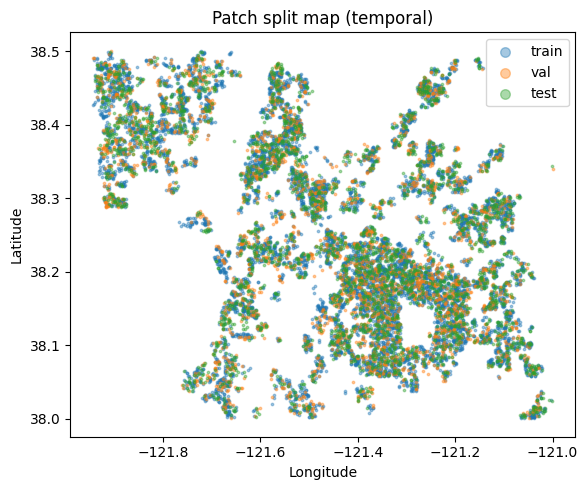

In [ ]:
manifest_lookup_full = manifest_details_df.set_index("file").to_dict("index")

if SPLIT_STRATEGY == "temporal":
    def _split_of(fname):
        y = manifest_lookup_full.get(fname, {}).get("year")
        if y in SPLIT_TRAIN_YEARS: return "train"
        if y == SPLIT_VAL_YEAR:    return "val"
        if y == SPLIT_TEST_YEAR:   return "test"
        return None
    split_assignment = {f: _split_of(f) for f in valid_files}

else:  # spatial_block
    def _block_id(lon, lat, size=GEO_BLOCK_SIZE_DEG):
        return (math.floor(lon / size), math.floor(lat / size))
    blocks = {}
    for f in valid_files:
        meta = manifest_lookup_full.get(f, {})
        lon, lat = meta.get("longitude"), meta.get("latitude")
        if lon is None or lat is None:
            continue
        blocks.setdefault(_block_id(lon, lat), []).append(f)
    block_ids = sorted(blocks.keys())
    rng_blocks = np.random.default_rng(SEED)
    rng_blocks.shuffle(block_ids)
    n_blocks = len(block_ids)
    n_train_blk = int(round(SPATIAL_SPLIT_FRACTIONS["train"] * n_blocks))
    n_val_blk   = int(round(SPATIAL_SPLIT_FRACTIONS["val"]   * n_blocks))
    train_blocks = set(block_ids[:n_train_blk])
    val_blocks   = set(block_ids[n_train_blk:n_train_blk + n_val_blk])
    test_blocks  = set(block_ids[n_train_blk + n_val_blk:])
    split_assignment = {}
    for bid, files_in_block in blocks.items():
        s = "train" if bid in train_blocks else ("val" if bid in val_blocks else "test")
        for f in files_in_block:
            split_assignment[f] = s
    print(f"Spatial blocks: {n_blocks} total (~{GEO_BLOCK_SIZE_DEG} deg each) "
          f"-> {len(train_blocks)} train / {len(val_blocks)} val / {len(test_blocks)} test blocks")

train_names_all = sorted(f for f, s in split_assignment.items() if s == "train")
val_names_all   = sorted(f for f, s in split_assignment.items() if s == "val")
test_names_all  = sorted(f for f, s in split_assignment.items() if s == "test")

assert (len(train_names_all) + len(val_names_all) + len(test_names_all) ==
        sum(1 for s in split_assignment.values() if s is not None)), \
    "Some patches were not assigned a split."

def _split_rows(names):
    out = []
    for f in names:
        meta = manifest_lookup_full.get(f, {})
        out.append({"file": f, "year": meta.get("year"), "longitude": meta.get("longitude"),
                    "latitude": meta.get("latitude"), "crop_label": meta.get("crop_label")})
    return pd.DataFrame(out)

train_split_df = _split_rows(train_names_all)
val_split_df   = _split_rows(val_names_all)
test_split_df  = _split_rows(test_names_all)
train_split_df.to_csv(TRAIN_CSV, index=False)
val_split_df.to_csv(VAL_CSV, index=False)
test_split_df.to_csv(TEST_CSV, index=False)

# no overlap between train / validation / test filenames
s_train, s_val, s_test = set(train_names_all), set(val_names_all), set(test_names_all)
assert not (s_train & s_val), "train/val overlap!"
assert not (s_train & s_test), "train/test overlap!"
assert not (s_val & s_test), "val/test overlap!"

run_manifest.update({
    "split_strategy_used": SPLIT_STRATEGY,
    "num_train_files": len(train_names_all), "num_val_files": len(val_names_all),
    "num_test_files": len(test_names_all),
})
save_manifest()

print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Train: {len(train_names_all)} | Val: {len(val_names_all)} | Test: {len(test_names_all)}")
print("No overlap between train/val/test filenames: confirmed.")
print("Saved:", TRAIN_CSV, "|", VAL_CSV, "|", TEST_CSV)

# diagnostic map of the split (helps visually confirm no leakage across nearby patches)
try:
    plt.figure(figsize=(6, 5))
    for name, df_, color in [("train", train_split_df, "tab:blue"),
                             ("val", val_split_df, "tab:orange"),
                             ("test", test_split_df, "tab:green")]:
        plt.scatter(df_["longitude"], df_["latitude"], s=3, alpha=0.4, label=name, color=color)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend(markerscale=4)
    plt.title(f"Patch split map ({SPLIT_STRATEGY})")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "figure_split_map.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Split map skipped:", e)


In [ ]:
class SRPairsDataset(Dataset):
    def __init__(self, pair_dir, file_names, max_items=None):
        self.pair_dir = Path(pair_dir)
        self.files = list(file_names)
        if max_items is not None:
            self.files = self.files[:max_items]
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        lr, hr = read_pair(self.pair_dir / self.files[idx])
        if hr.max() > 2.0 or lr.max() > 2.0:      # safety: rescale if stored as raw DN
            hr = hr / 10000.0; lr = lr / 10000.0
        hr = np.clip(hr, 0, 1).astype(np.float32)
        lr = np.clip(lr, 0, 1).astype(np.float32)
        return (torch.from_numpy(np.transpose(lr, (2, 0, 1))),
                torch.from_numpy(np.transpose(hr, (2, 0, 1))))

MAX_TRAIN = None
MAX_VAL   = None
BATCH_SIZE = 16 if str(device) == "cuda" else 4

train_ds = SRPairsDataset(PAIRS_DIR, train_names_all, max_items=MAX_TRAIN)
val_ds   = SRPairsDataset(PAIRS_DIR, val_names_all,   max_items=MAX_VAL)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
# The test set is deliberately NOT wrapped in a batched DataLoader: Part 7 evaluates it one
# patch at a time so every reported metric is a genuine per-patch value, never a batch
# average (see Part 7 for why that matters for a credible final result).
run_manifest["num_train_patches_used"] = len(train_ds)
run_manifest["num_val_patches_used"] = len(val_ds)
run_manifest["num_test_patches_used"] = len(test_names_all)
save_manifest()

lr_b, hr_b = next(iter(train_loader))
print("Train:", len(train_ds), "| Val:", len(val_ds), "| Test:", len(test_names_all))
print("LR batch:", tuple(lr_b.shape), "| HR batch:", tuple(hr_b.shape))


Train: 9000 | Val: 3000 | Test: 3000
LR batch: (16, 4, 32, 32) | HR batch: (16, 4, 128, 128)


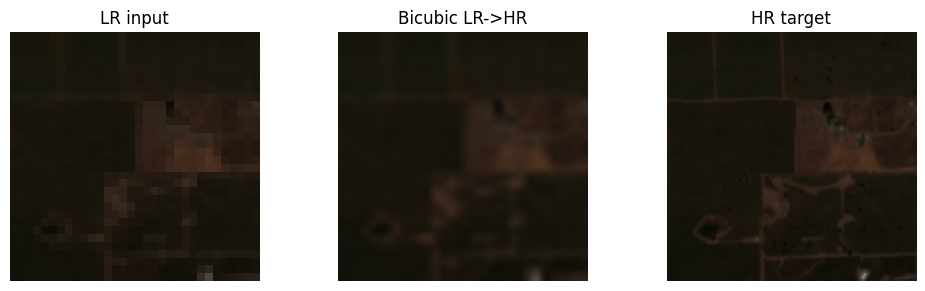

In [ ]:
# data sanity figure (LR vs bicubic-upsampled vs HR)
def chw_to_hwc(x):
    if x.ndim == 4:
        x = x[0]
    return np.transpose(x.detach().cpu().numpy(), (1, 2, 0))
def rgb_like(img):
    return np.clip(img[..., :3], 0, 1) if img.shape[-1] >= 3 else np.repeat(np.clip(img[..., :1], 0, 1), 3, axis=-1)

lr0, hr0 = lr_b[0:1], hr_b[0:1]
lr0_up = F.interpolate(lr0, size=hr0.shape[-2:], mode="bicubic", align_corners=False)
plt.figure(figsize=(10, 3))
for i, (title, ten) in enumerate([("LR input", lr0), ("Bicubic LR->HR", lr0_up), ("HR target", hr0)], 1):
    plt.subplot(1, 3, i); plt.imshow(rgb_like(chw_to_hwc(ten))); plt.title(title); plt.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "figure_data_sanity_patch.png", dpi=200, bbox_inches="tight"); plt.show()

# Part 6 — Scale-aware super-resolution model, metrics, training

One model: a residual CNN that bicubic-upsamples the LR input by the **detected** scale, then learns a residual correction. Metrics include image-quality (PSNR, MAE, MSE, optional SSIM) and a **vegetation-signal** metric (NDVI RMSE) computed with the correct band indices. We measure the bicubic baseline first, then train with early stopping.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, padding=1)
        self.conv2 = nn.Conv2d(c, c, 3, padding=1)
    def forward(self, x):
        return F.relu(x + self.conv2(F.relu(self.conv1(x))))

class ResidualSRNet(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_blocks=6, scale=2):
        super().__init__()
        self.scale = scale
        self.entry = nn.Conv2d(in_channels, hidden_channels, 5, padding=2)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_channels) for _ in range(num_blocks)])
        self.exit = nn.Conv2d(hidden_channels, in_channels, 3, padding=1)
    def forward(self, x):
        x_up = F.interpolate(x, scale_factor=self.scale, mode="bicubic", align_corners=False)
        h = F.relu(self.entry(x_up))
        h = self.blocks(h)
        return torch.clamp(x_up + self.exit(h), 0, 1)

model = ResidualSRNet(in_channels=IN_CHANNELS, hidden_channels=64, num_blocks=6, scale=DETECTED_SCALE).to(device)
print(model)

ResidualSRNet(
  (entry): Conv2d(4, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (4): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2

In [ ]:
def mae_t(a, b):  return F.l1_loss(a, b).item()
def mse_t(a, b):  return F.mse_loss(a, b).item()
def psnr_t(a, b):
    m = F.mse_loss(a, b).item()
    return float("inf") if m == 0 else -10 * math.log10(m)
def grad_loss(p, t):
    return (F.l1_loss(p[:, :, :, 1:] - p[:, :, :, :-1], t[:, :, :, 1:] - t[:, :, :, :-1]) +
            F.l1_loss(p[:, :, 1:, :] - p[:, :, :-1, :], t[:, :, 1:, :] - t[:, :, :-1, :]))
def sr_loss(p, t):
    return F.l1_loss(p, t) + 0.05 * grad_loss(p, t)

def compute_ndvi_tensor(x, red_idx=RED_IDX, nir_idx=NIR_IDX, eps=1e-6):
    if x.shape[1] <= max(red_idx, nir_idx):
        return None
    red = x[:, red_idx:red_idx+1]; nir = x[:, nir_idx:nir_idx+1]
    return torch.clamp((nir - red) / (nir + red + eps), -1, 1)
def ndvi_rmse_t(a, b):
    na, nb = compute_ndvi_tensor(a), compute_ndvi_tensor(b)
    if na is None or nb is None:
        return np.nan
    return torch.sqrt(F.mse_loss(na, nb)).item()

def ssim_metric(a, b):
    if not SKIMAGE_AVAILABLE:
        return np.nan
    A = a.detach().cpu().numpy(); B = b.detach().cpu().numpy()
    vals = []
    for i in range(A.shape[0]):
        ah = np.transpose(A[i], (1, 2, 0)); bh = np.transpose(B[i], (1, 2, 0))
        vals.append(ssim(ah, bh, data_range=1.0, channel_axis=-1))
    return float(np.mean(vals))

# quick correctness self-check of the NDVI band order
_t = torch.zeros(1, IN_CHANNELS, 4, 4); _t[:, RED_IDX] = 0.1; _t[:, NIR_IDX] = 0.5
_nd = compute_ndvi_tensor(_t)
print("NDVI band-order self-check:", round(float(_nd.mean()), 4), "(expected ~0.6667 for veg)")
print("Metric helpers ready.")

NDVI band-order self-check: 0.6667 (expected ~0.6667 for veg)
Metric helpers ready.


In [ ]:
# NOTE: this is a coarse, BATCH-AVERAGED sanity check on the VALIDATION set only, used
# purely as a quick pre-training signal. It is NOT the reported result -- the paper's
# numbers come from the per-patch TEST-set evaluation in Part 7, which avoids batch-size
# dependence entirely by scoring one patch at a time.
def evaluate_bicubic(loader):
    rows = []
    for lr, hr in loader:
        lr = lr.to(device); hr = hr.to(device)
        bic = torch.clamp(F.interpolate(lr, size=hr.shape[-2:], mode="bicubic", align_corners=False), 0, 1)
        rows.append({"mae": mae_t(bic, hr), "mse": mse_t(bic, hr), "psnr": psnr_t(bic, hr),
                     "ndvi_rmse": ndvi_rmse_t(bic, hr), "ssim": ssim_metric(bic, hr)})
    return pd.DataFrame(rows).mean(numeric_only=True).to_dict()

bicubic_metrics = evaluate_bicubic(val_loader)
print("Bicubic baseline (validation, batch-mean, diagnostic only):",
      {k: round(v, 5) for k, v in bicubic_metrics.items()})


Bicubic baseline (validation, batch-mean, diagnostic only): {'mae': 0.00868, 'mse': 0.00024, 'psnr': 36.3401, 'ndvi_rmse': 0.06237, 'ssim': 0.90816}


In [ ]:
LEARNING_RATE = 5e-4
NUM_EPOCHS    = 30
PATIENCE      = 8

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_val_loss = float("inf"); best_epoch = -1; epochs_no_improve = 0
history = []
best_model_path = CHECKPOINT_DIR / "best_sr_model.pt"

# NOTE: also a batch-averaged, VALIDATION-set-only diagnostic, used only to pick the
# best checkpoint (early stopping). The final reported TEST metrics are computed
# per-patch in Part 7, not from this function.
def evaluate_model():
    model.eval(); rows = []
    with torch.no_grad():
        for lr, hr in val_loader:
            lr = lr.to(device); hr = hr.to(device); pred = model(lr)
            rows.append({"loss": sr_loss(pred, hr).item(), "mae": mae_t(pred, hr), "mse": mse_t(pred, hr),
                         "psnr": psnr_t(pred, hr), "ndvi_rmse": ndvi_rmse_t(pred, hr),
                         "ssim": ssim_metric(pred, hr)})
    return pd.DataFrame(rows).mean(numeric_only=True).to_dict()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train(); losses = []
    for lr, hr in train_loader:
        lr = lr.to(device); hr = hr.to(device)
        optimizer.zero_grad()
        loss = sr_loss(model(lr), hr)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    train_loss = float(np.mean(losses))
    vm = evaluate_model()
    history.append({"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in vm.items()}})
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_loss={train_loss:.5f} | "
          f"val_loss={vm['loss']:.5f} | val_psnr={vm['psnr']:.3f}")
    if vm["loss"] < best_val_loss:
        best_val_loss = vm["loss"]; best_epoch = epoch; epochs_no_improve = 0
        torch.save({"model_state_dict": model.state_dict(), "scale": DETECTED_SCALE,
                    "in_channels": IN_CHANNELS, "epoch": epoch, "val_metrics": vm}, best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping."); break

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "sr_training_history.csv", index=False)
display(history_df.tail())
print("Best epoch:", best_epoch, "| saved:", best_model_path)

Epoch 01/30 | train_loss=0.00914 | val_loss=0.00864 | val_psnr=36.944
Epoch 02/30 | train_loss=0.00813 | val_loss=0.00842 | val_psnr=37.119
Epoch 03/30 | train_loss=0.00795 | val_loss=0.00826 | val_psnr=37.266
Epoch 04/30 | train_loss=0.00782 | val_loss=0.00816 | val_psnr=37.358
Epoch 05/30 | train_loss=0.00772 | val_loss=0.00809 | val_psnr=37.429
Epoch 06/30 | train_loss=0.00764 | val_loss=0.00799 | val_psnr=37.527
Epoch 07/30 | train_loss=0.00757 | val_loss=0.00795 | val_psnr=37.585
Epoch 08/30 | train_loss=0.00753 | val_loss=0.00797 | val_psnr=37.556
Epoch 09/30 | train_loss=0.00747 | val_loss=0.00787 | val_psnr=37.652
Epoch 10/30 | train_loss=0.00743 | val_loss=0.00783 | val_psnr=37.690
Epoch 11/30 | train_loss=0.00740 | val_loss=0.00780 | val_psnr=37.719
Epoch 12/30 | train_loss=0.00737 | val_loss=0.00783 | val_psnr=37.706
Epoch 13/30 | train_loss=0.00733 | val_loss=0.00777 | val_psnr=37.772
Epoch 14/30 | train_loss=0.00730 | val_loss=0.00772 | val_psnr=37.834
Epoch 15/30 | train_

,epoch,train_loss,val_loss,val_mae,val_mse,val_psnr,val_ndvi_rmse,val_ssim
25,26,0.007085,0.007511,0.006879,0.000160,38.051682,0.047192,0.938372
26,27,0.007069,0.007557,0.006922,0.000163,37.978182,0.047994,0.937619
27,28,0.007058,0.007524,0.006892,0.000161,38.027247,0.046538,0.937845
28,29,0.007048,0.007498,0.006867,0.000160,38.060872,0.046707,0.938394
29,30,0.007036,0.007499,0.006868,0.000160,38.054629,0.046559,0.938375


Best epoch: 29 | saved: /content/checkpoints/best_sr_model.pt


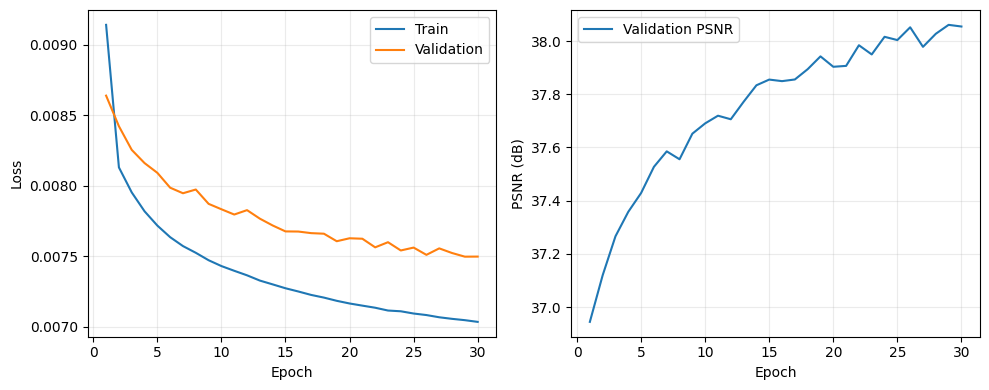

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.25)
axes[1].plot(history_df["epoch"], history_df["val_psnr"], label="Validation PSNR")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PSNR (dB)"); axes[1].legend(); axes[1].grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_sr_training_curves.png", dpi=250, bbox_inches="tight"); plt.show()

# Part 7 — Final evaluation: per-patch test-set metrics (model vs. bicubic)

Everything reported here comes **only from the held-out test set** (`test_files.csv`),
never from validation. Each metric (MAE, MSE, PSNR, SSIM, NDVI RMSE) is computed **per
patch** for bicubic upsampling and for the trained model, then the two per-patch series
are compared as a **paired** sample (same patches, two methods) instead of two independent
batch-mean numbers. This removes the batch-size dependence of the old evaluation and stops
the final (possibly smaller) mini-batch from being weighted the same as a full batch.

Outputs: `test_patch_metrics.csv` (one row per test patch), `sr_bicubic_vs_model_metrics.csv`
(mean/std/median/95% CI per metric per method, plus the paired model-minus-bicubic
difference and a paired t-test p-value), and `sr_metrics_by_crop.csv` (the same comparison
broken out by crop, so crop-specific claims are backed by crop-specific test evidence).


In [ ]:
# reload best checkpoint (weights_only=False so the metadata dict loads on new PyTorch)
checkpoint = torch.load(best_model_path, map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device); model.eval()
print("Reloaded best model from epoch", checkpoint.get("epoch"))

manifest_lookup = manifest_details_df.set_index("file").to_dict("index")

def eval_one_test_patch(fname):
    """Score exactly ONE patch: bicubic vs model, both compared to its own HR target.
    No batching, no averaging across patches here -- that happens afterwards on the
    per-patch rows, which is what keeps the final numbers batch-size independent."""
    lr, hr = read_pair(PAIRS_DIR / fname)
    if hr.max() > 2.0 or lr.max() > 2.0:
        hr = hr / 10000.0; lr = lr / 10000.0
    hr = np.clip(hr, 0, 1).astype(np.float32); lr = np.clip(lr, 0, 1).astype(np.float32)
    lr_t = torch.from_numpy(np.transpose(lr, (2, 0, 1))).unsqueeze(0).to(device)
    hr_t = torch.from_numpy(np.transpose(hr, (2, 0, 1))).unsqueeze(0).to(device)
    with torch.no_grad():
        bic = torch.clamp(F.interpolate(lr_t, size=hr_t.shape[-2:], mode="bicubic", align_corners=False), 0, 1)
        pred = model(lr_t)
    meta = manifest_lookup.get(fname, {})
    row = {
        "file": fname, "year": meta.get("year"), "crop_label": meta.get("crop_label"),
        "crop_fraction": meta.get("crop_fraction"),
        "bicubic_mae": mae_t(bic, hr_t), "model_mae": mae_t(pred, hr_t),
        "bicubic_mse": mse_t(bic, hr_t), "model_mse": mse_t(pred, hr_t),
        "bicubic_psnr": psnr_t(bic, hr_t), "model_psnr": psnr_t(pred, hr_t),
        "bicubic_ssim": ssim_metric(bic, hr_t), "model_ssim": ssim_metric(pred, hr_t),
        "bicubic_ndvi_rmse": ndvi_rmse_t(bic, hr_t), "model_ndvi_rmse": ndvi_rmse_t(pred, hr_t),
    }
    return row, (lr_t.cpu(), bic.cpu(), pred.cpu(), hr_t.cpu())

test_patch_rows = []
test_examples = []   # first few test patches, kept for the qualitative figures below
for fname in test_names_all:
    row, tensors = eval_one_test_patch(fname)
    test_patch_rows.append(row)
    if len(test_examples) < 3:
        lr_t, bic_t, pred_t, hr_t = tensors
        test_examples.append({"lr": lr_t[0], "bicubic": bic_t[0], "model": pred_t[0], "hr": hr_t[0]})

test_patch_metrics_df = pd.DataFrame(test_patch_rows)
test_patch_metrics_df.to_csv(RESULTS_DIR / "test_patch_metrics.csv", index=False)
print("Saved per-patch test metrics:", RESULTS_DIR / "test_patch_metrics.csv",
      "| rows:", len(test_patch_metrics_df))
display(test_patch_metrics_df.head())


Reloaded best model from epoch 29
Saved per-patch test metrics: /content/results/test_patch_metrics.csv | rows: 3000


,file,year,crop_label,crop_fraction,bicubic_mae,model_mae,bicubic_mse,model_mse,bicubic_psnr,model_psnr,bicubic_ssim,model_ssim,bicubic_ndvi_rmse,model_ndvi_rmse
0,S2_2022_m121.00092_38.02455.npz,2022,GRAPES,0.368239,0.008665,0.006151,0.000204,0.000117,36.911095,39.310590,0.900671,0.944436,0.073731,0.052947
1,S2_2022_m121.00116_38.34327.npz,2022,ALFALFA,0.415443,0.008318,0.006978,0.000199,0.000156,37.011790,38.061111,0.905580,0.931777,0.065536,0.053766
2,S2_2022_m121.00630_38.02565.npz,2022,GRAPES,0.515860,0.007362,0.005203,0.000158,0.000083,38.025887,40.790276,0.922133,0.960810,0.059676,0.041097
3,S2_2022_m121.01532_38.01046.npz,2022,GRAPES,0.448146,0.007751,0.005901,0.000149,0.000091,38.282613,40.402101,0.915446,0.948877,0.061106,0.041641
4,S2_2022_m121.01624_38.01414.npz,2022,GRAPES,0.379558,0.007706,0.006048,0.000164,0.000107,37.864045,39.711819,0.921469,0.947677,0.056192,0.040394


In [ ]:
def mean_ci95(x):
    """Mean, std, median, and a normal-approximation 95% CI, ignoring non-finite values."""
    x = np.asarray(pd.to_numeric(x, errors="coerce"), dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return dict(n=0, mean=np.nan, std=np.nan, median=np.nan, ci95_low=np.nan, ci95_high=np.nan)
    m = float(x.mean()); s = float(x.std(ddof=1)) if n > 1 else 0.0
    se = s / math.sqrt(n) if n > 0 else np.nan
    return dict(n=n, mean=m, std=s, median=float(np.median(x)),
               ci95_low=m - 1.96 * se, ci95_high=m + 1.96 * se)

METRIC_NAMES = ["mae", "mse", "psnr", "ssim", "ndvi_rmse"]
LOWER_IS_BETTER = {"mae", "mse", "ndvi_rmse"}

summary_rows = []
for metric in METRIC_NAMES:
    for method in ["bicubic", "model"]:
        stats = mean_ci95(test_patch_metrics_df[f"{method}_{metric}"])
        stats.update({"metric": metric, "method": method})
        summary_rows.append(stats)
    # paired comparison: bicubic and model are scored on the SAME patches, so compare the
    # per-patch differences directly rather than two independent-sample summaries
    diff = test_patch_metrics_df[f"model_{metric}"] - test_patch_metrics_df[f"bicubic_{metric}"]
    dstats = mean_ci95(diff)
    dstats.update({"metric": metric, "method": "model_minus_bicubic_paired"})
    if SCIPY_AVAILABLE:
        finite_idx = diff[np.isfinite(diff)].index
        if len(finite_idx) > 1:
            _, pval = scipy_stats.ttest_rel(
                test_patch_metrics_df.loc[finite_idx, f"model_{metric}"],
                test_patch_metrics_df.loc[finite_idx, f"bicubic_{metric}"])
            dstats["paired_p_value"] = float(pval)
    summary_rows.append(dstats)

test_metrics_summary_df = pd.DataFrame(summary_rows)
front_cols = ["metric", "method", "n", "mean", "std", "median", "ci95_low", "ci95_high"]
other_cols = [c for c in test_metrics_summary_df.columns if c not in front_cols]
test_metrics_summary_df = test_metrics_summary_df[front_cols + other_cols]
test_metrics_summary_df.to_csv(RESULTS_DIR / "sr_bicubic_vs_model_metrics.csv", index=False)
display(test_metrics_summary_df.round(5))

def _mean_of(metric, method):
    r = test_metrics_summary_df[(test_metrics_summary_df["metric"] == metric) &
                                (test_metrics_summary_df["method"] == method)]
    return float(r["mean"].iloc[0]) if len(r) else float("nan")

psnr_b, psnr_m = _mean_of("psnr", "bicubic"), _mean_of("psnr", "model")
ndvi_b, ndvi_m = _mean_of("ndvi_rmse", "bicubic"), _mean_of("ndvi_rmse", "model")
print(f"\nTest-set mean PSNR - bicubic: {psnr_b:.3f} dB | model: {psnr_m:.3f} dB "
      f"(n={len(test_patch_metrics_df)} patches)")
print(f"Test-set mean NDVI RMSE - bicubic: {ndvi_b:.4f} | model: {ndvi_m:.4f}")
if psnr_m <= psnr_b:
    print("GUARDRAIL: model did NOT beat bicubic on mean test PSNR. "
          "Report it as a baseline, do not claim SR improvement.")


,metric,method,n,mean,std,median,ci95_low,ci95_high,paired_p_value
0,mae,bicubic,3000,0.00873,0.00210,0.00849,0.00865,0.00880,NaN
1,mae,model,3000,0.00683,0.00189,0.00653,0.00677,0.00690,NaN
2,mae,model_minus_bicubic_paired,3000,-0.00189,0.00067,-0.00184,-0.00192,-0.00187,0.0
3,mse,bicubic,3000,0.00024,0.00011,0.00022,0.00024,0.00025,NaN
4,mse,model,3000,0.00016,0.00009,0.00014,0.00016,0.00017,NaN
5,mse,model_minus_bicubic_paired,3000,-0.00008,0.00004,-0.00007,-0.00008,-0.00008,0.0
6,psnr,bicubic,3000,36.59267,1.95192,36.51895,36.52282,36.66251,NaN
7,psnr,model,3000,38.46435,2.20702,38.49671,38.38537,38.54332,NaN
8,psnr,model_minus_bicubic_paired,3000,1.87168,0.80937,1.74469,1.84272,1.90064,0.0
9,ssim,bicubic,3000,0.90716,0.02707,0.91023,0.90619,0.90813,NaN



Test-set mean PSNR - bicubic: 36.593 dB | model: 38.464 dB (n=3000 patches)
Test-set mean NDVI RMSE - bicubic: 0.0669 | model: 0.0494


In [ ]:
crop_rows = []
for crop, sub in test_patch_metrics_df.groupby("crop_label", dropna=False):
    crop_rows.append({
        "crop": crop if pd.notna(crop) else "unlabeled",
        "test_patches": int(len(sub)),
        "bicubic_psnr": float(sub["bicubic_psnr"].mean()),
        "model_psnr": float(sub["model_psnr"].mean()),
        "bicubic_ndvi_rmse": float(sub["bicubic_ndvi_rmse"].mean()),
        "model_ndvi_rmse": float(sub["model_ndvi_rmse"].mean()),
    })
sr_metrics_by_crop_df = pd.DataFrame(crop_rows).sort_values("test_patches", ascending=False).reset_index(drop=True)
sr_metrics_by_crop_df.to_csv(RESULTS_DIR / "sr_metrics_by_crop.csv", index=False)
display(sr_metrics_by_crop_df.round(4))

thin_crops = sr_metrics_by_crop_df.loc[
    sr_metrics_by_crop_df["test_patches"] < MIN_TEST_CROP_COUNT, "crop"].tolist()
if thin_crops:
    print(f"NOTE: {thin_crops} have fewer than {MIN_TEST_CROP_COUNT} test patches. "
          "SR performance is not equally demonstrated for these crops -- report per-crop "
          "numbers, and do not extend the aggregate PSNR/NDVI-RMSE claim to them without "
          "this caveat.")
if "CITRUS" in sr_metrics_by_crop_df["crop"].values:
    citrus_n = int(sr_metrics_by_crop_df.loc[sr_metrics_by_crop_df["crop"] == "CITRUS", "test_patches"].iloc[0])
    if citrus_n < MIN_TEST_CROP_COUNT:
        print(f"NOTE: citrus has only {citrus_n} test patches -- do not claim citrus SR "
              "performance is 'equally demonstrated' relative to the other crops.")
elif "CITRUS" in CROP_CODES:
    print("NOTE: citrus is entirely absent from the test set -- SR performance cannot be claimed for citrus.")


,crop,test_patches,bicubic_psnr,model_psnr,bicubic_ndvi_rmse,model_ndvi_rmse
0,GRAPES,1846,36.7111,38.5142,0.0660,0.0497
1,ALFALFA,781,35.8895,37.8441,0.0728,0.0518
2,ALMOND,373,37.4789,39.5160,0.0584,0.0426


NOTE: citrus is entirely absent from the test set -- SR performance cannot be claimed for citrus.


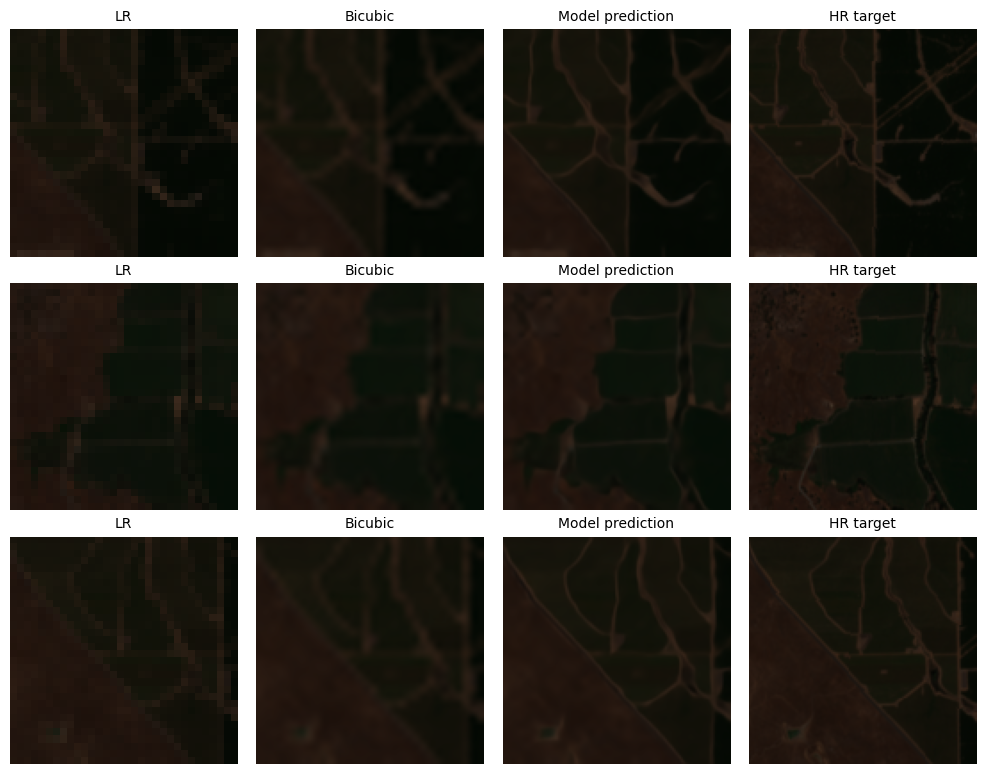

In [ ]:
# qualitative figure from the held-out TEST set (final-results examples, not validation)
examples = test_examples
fig, axes = plt.subplots(len(examples), 4, figsize=(10, 2.6*len(examples)))
if len(examples) == 1:
    axes = np.array([axes])
titles = ["LR", "Bicubic", "Model prediction", "HR target"]
for r, ex in enumerate(examples):
    for c, key in enumerate(["lr", "bicubic", "model", "hr"]):
        axes[r, c].imshow(rgb_like(chw_to_hwc(ex[key]))); axes[r, c].set_title(titles[c], fontsize=10)
        axes[r, c].axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_sr_visual_comparison.png", dpi=250, bbox_inches="tight"); plt.show()


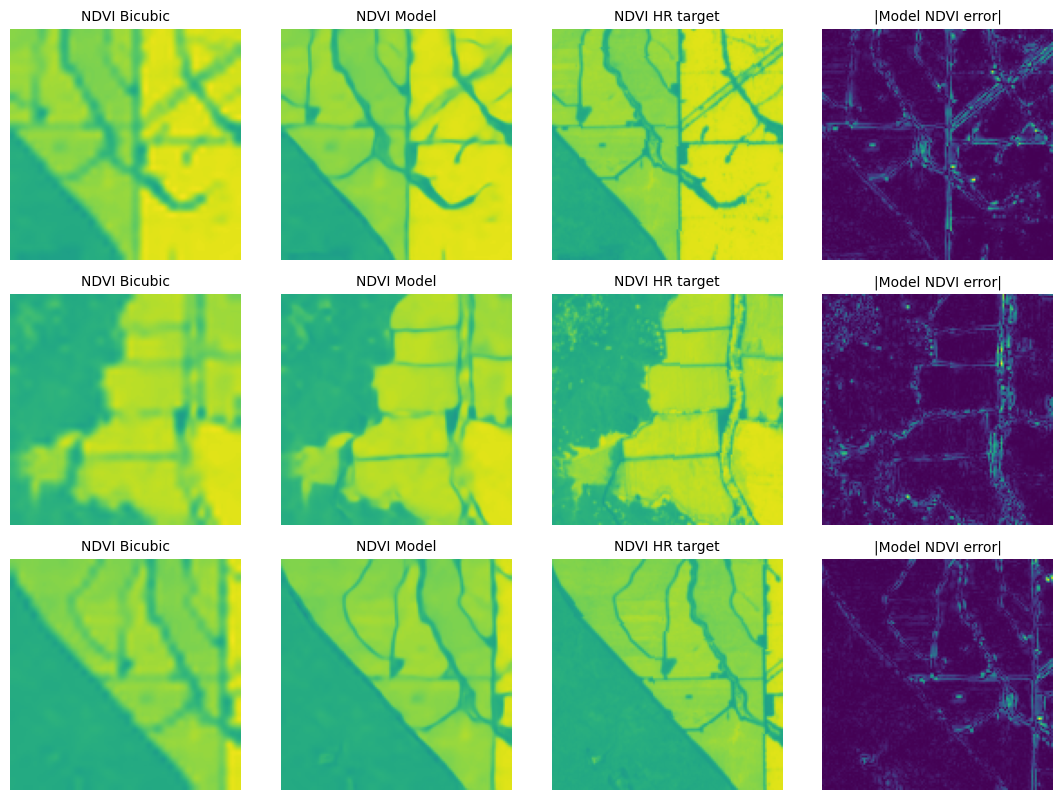

NDVI RMSE (test set) - bicubic: 0.0669 | model: 0.0494 | model better


In [ ]:
# NDVI-recovery figure (uses the correct RED/NIR indices), from the TEST set
def tensor_to_ndvi_2d(x_chw):
    nd = compute_ndvi_tensor(x_chw.unsqueeze(0))
    return None if nd is None else nd.squeeze().detach().cpu().numpy()

if IN_CHANNELS <= max(RED_IDX, NIR_IDX):
    print("Not enough channels to compute NDVI - skipping NDVI impact figure.")
else:
    fig, axes = plt.subplots(len(examples), 4, figsize=(11, 2.7*len(examples)))
    if len(examples) == 1:
        axes = np.array([axes])
    for r, ex in enumerate(examples):
        ndvi_bic = tensor_to_ndvi_2d(ex["bicubic"])
        ndvi_mod = tensor_to_ndvi_2d(ex["model"])
        ndvi_hr  = tensor_to_ndvi_2d(ex["hr"])
        ndvi_err = np.abs(ndvi_mod - ndvi_hr)
        panels = [ndvi_bic, ndvi_mod, ndvi_hr, ndvi_err]
        ptitles = ["NDVI Bicubic", "NDVI Model", "NDVI HR target", "|Model NDVI error|"]
        for c, (panel, title) in enumerate(zip(panels, ptitles)):
            vmax = 1 if c < 3 else max(0.3, float(np.nanmax(ndvi_err)))
            axes[r, c].imshow(panel, vmin=(-1 if c < 3 else 0), vmax=vmax)
            axes[r, c].set_title(title, fontsize=10); axes[r, c].axis("off")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "figure_ndvi_impact.png", dpi=250, bbox_inches="tight"); plt.show()
    # quantify NDVI recovery improvement (test-set mean, from Part 7's per-patch summary)
    print(f"NDVI RMSE (test set) - bicubic: {ndvi_b:.4f} | model: {ndvi_m:.4f} | "
          f"{'model better' if ndvi_m < ndvi_b else 'bicubic better'}")


# Part 8 — Manuscript snippets, manifest, output checklist

Exports a Markdown file of real metrics and provenance (including the split strategy that
was actually used and per-crop test coverage), marks the run paper-ready only if no
fallback was used, and verifies the expected outputs exist.


In [ ]:
paper_ready = ((("real" in str(run_manifest["baseline_data_source"])) or
                ("cached_csv" in str(run_manifest["baseline_data_source"]))) and
               (("real" in str(run_manifest["sr_pair_data_source"])) or
                ("cached_real" in str(run_manifest["sr_pair_data_source"]))))
run_manifest["paper_ready"] = bool(paper_ready)
save_manifest()

sig = baseline_summary.dropna(subset=["percent_change"])
strongest = sig.iloc[sig["percent_change"].abs().argmax()] if len(sig) else None

n_train = run_manifest.get("num_train_patches_used")
n_val   = run_manifest.get("num_val_patches_used")
n_test  = run_manifest.get("num_test_patches_used")
strategy_used = run_manifest.get("split_strategy_used")
patch_km = PATCH_SIZE_HR * HR_SCALE_METERS / 1000.0

if strategy_used == "temporal":
    split_line = (f"Patches were split chronologically to avoid same-composite leakage between "
                  f"nearby/overlapping ~{patch_km:.2f} km patches drawn from the same seasonal "
                  f"composite: train = {SPLIT_TRAIN_YEARS}, validation = {SPLIT_VAL_YEAR}, "
                  f"test = {SPLIT_TEST_YEAR}.")
else:
    under = run_manifest.get("split_underrepresented_crops_in_test_year")
    split_line = (f"A chronological split was rejected because {under} were nearly absent from "
                  f"{SPLIT_TEST_YEAR}. Instead, patches were assigned to whole "
                  f"~{GEO_BLOCK_SIZE_DEG} deg geographic blocks, and entire blocks (never "
                  f"individual patches) were randomly assigned to train/validation/test, so "
                  f"nearby or overlapping patches cannot appear on both sides of the split.")
size_line = (f"Resulting sizes: {n_train} train / {n_val} validation / {n_test} test patches "
            f"(data_pairs/sr_pairs_x4/train_files.csv, val_files.csv, test_files.csv).")

dominant_crop_line = (
    f"The dataset is dominated by {dominant_crop} ({dominant_share*100:.1f}% of all "
    f"{len(manifest_details_df)} patches); counts by crop and year are in "
    f"results/dataset_summary.csv and results/patch_counts_by_year_crop.csv.")
thin_crop_line = (
    f"Crops with fewer than {MIN_TEST_CROP_COUNT} test patches ({thin_crops}) are reported "
    "individually in results/sr_metrics_by_crop.csv and should not be described as equally "
    "demonstrated." if thin_crops else
    "Every target crop has at least the minimum number of test patches; see "
    "results/sr_metrics_by_crop.csv for the per-crop breakdown.")

lines = [
    "# Generated Results Snippets",
    "",
    "## Provenance",
    f"- Baseline NDVI source: {run_manifest['baseline_data_source']}",
    f"- SR pair source: {run_manifest['sr_pair_data_source']}",
    f"- Hydro-year labels source: {run_manifest.get('year_labels_source')} "
    "(results/annual_precipitation_labels.csv)",
    f"- Paper-ready: {run_manifest['paper_ready']}",
    f"- Detected SR scale: x{DETECTED_SCALE} | input channels: {IN_CHANNELS} | band order: {SR_BANDS}",
    f"- Train/val/test patches used: {n_train}/{n_val}/{n_test}",
    "",
    "## Methods (data + SR)",
    "HR patches of 128x128 pixels were extracted from Sentinel-2 growing-season median composites over "
    "USDA CDL crop pixels (alfalfa, almond, citrus, grapes) in the northern Central Valley. LR patches were "
    "produced by 4x area-averaging, giving 32x32 inputs. Bands were B4, B3, B2, B8 (red, green, blue, NIR). "
    "A residual CNN bicubic-upsampled the LR input by the detected scale factor and learned a residual correction.",
    "",
    "## Split strategy",
    f"Strategy used: **{strategy_used}**. " + split_line,
    size_line,
    "",
    "## Dataset composition",
    dominant_crop_line,
    "",
    "## Baseline NDVI result",
]
if strongest is not None:
    lines.append(
        f"Across crops, {strongest['crop'].title()} showed the largest wet-to-drought NDVI change "
        f"({strongest['drought_minus_wet']:+.3f}, {strongest['percent_change']:+.1f}%"
        + (f", Welch p={strongest['welch_p_value']:.3g}" if not np.isnan(strongest.get('welch_p_value', np.nan)) else "")
        + "). Full per-crop values are in results/baseline_ndvi_summary.csv. Wet/drought labels are "
        "derived from real PRISM annual precipitation (results/annual_precipitation_labels.csv), "
        "not hand-assigned.")
else:
    lines.append("See results/baseline_ndvi_summary.csv for per-crop wet-vs-drought NDVI values.")
lines += [
    "",
    f"## Super-resolution performance (TEST set only, n={len(test_patch_metrics_df)} patches, "
    "per-patch paired evaluation)",
    f"Bicubic PSNR {psnr_b:.3f} dB vs model PSNR {psnr_m:.3f} dB (mean of per-patch values; see "
    "results/sr_bicubic_vs_model_metrics.csv for std/median/95% CI and the paired "
    f"model-minus-bicubic difference). NDVI RMSE bicubic {ndvi_b:.4f} vs model {ndvi_m:.4f}.",
    thin_crop_line,
    "",
    "## Guardrail",
    "If the model does not beat bicubic on the test set, describe it as a baseline and discuss "
    "limitations rather than claiming a super-resolution improvement. Only the test-set numbers "
    "above are reported as final results; validation-set numbers were used solely for model "
    "selection (early stopping) and never appear as a reported result.",
]
snippet = "\n".join(lines)
with open(PAPER_DIR / "generated_results_snippets.md", "w") as f:
    f.write(snippet)
print(snippet)


# Generated Results Snippets

## Provenance
- Baseline NDVI source: earth_engine_real:COPERNICUS/S2_SR_HARMONIZED+USDA/NASS/CDL
- SR pair source: None
- Hydro-year labels source: earth_engine_real:PRISM/ANm (results/annual_precipitation_labels.csv)
- Paper-ready: False
- Detected SR scale: x4 | input channels: 4 | band order: ['B4', 'B3', 'B2', 'B8']
- Train/val/test patches used: 9000/3000/3000

## Methods (data + SR)
HR patches of 128x128 pixels were extracted from Sentinel-2 growing-season median composites over USDA CDL crop pixels (alfalfa, almond, citrus, grapes) in the northern Central Valley. LR patches were produced by 4x area-averaging, giving 32x32 inputs. Bands were B4, B3, B2, B8 (red, green, blue, NIR). A residual CNN bicubic-upsampled the LR input by the detected scale factor and learned a residual correction.

## Split strategy
Strategy used: **temporal**. Patches were split chronologically to avoid same-composite leakage between nearby/overlapping ~1.28 km patches draw

In [ ]:
expected_outputs = [
    RESULTS_DIR / "run_manifest.json",
    BASELINE_CSV,
    RESULTS_DIR / "baseline_ndvi_summary.csv",
    RESULTS_DIR / "annual_precipitation_labels.csv",
    RESULTS_DIR / "data_audit.csv",
    RESULTS_DIR / "manifest_details.csv",
    RESULTS_DIR / "dataset_summary.csv",
    RESULTS_DIR / "patch_counts_by_year_crop.csv",
    TRAIN_CSV, VAL_CSV, TEST_CSV,
    RESULTS_DIR / "sr_training_history.csv",
    RESULTS_DIR / "test_patch_metrics.csv",
    RESULTS_DIR / "sr_bicubic_vs_model_metrics.csv",
    RESULTS_DIR / "sr_metrics_by_crop.csv",
    FIG_DIR / "figure_baseline_ndvi_by_crop.png",
    FIG_DIR / "figure_data_sanity_patch.png",
    FIG_DIR / "figure_split_map.png",
    FIG_DIR / "figure_sr_training_curves.png",
    FIG_DIR / "figure_sr_visual_comparison.png",
    FIG_DIR / "figure_ndvi_impact.png",
    CHECKPOINT_DIR / "best_sr_model.pt",
    PAPER_DIR / "generated_results_snippets.md",
]
check_df = pd.DataFrame({"path": [str(p) for p in expected_outputs],
                         "exists": [p.exists() for p in expected_outputs]})
display(check_df)
print("\nPaper-ready according to manifest:", run_manifest["paper_ready"])
if not run_manifest["paper_ready"]:
    print("WARNING: outputs are not marked paper-ready. Rebuild from real Earth Engine data before submission.")
else:
    print("All steps used real data. Tables and figures are in results/ and figures/paper/.")


,path,exists
0,/content/results/run_manifest.json,True
1,/content/results/baseline_ndvi_all_crops.csv,True
2,/content/results/baseline_ndvi_summary.csv,True
3,/content/results/annual_precipitation_labels.csv,True
4,/content/results/data_audit.csv,True
5,/content/results/manifest_details.csv,True
6,/content/results/dataset_summary.csv,True
7,/content/results/patch_counts_by_year_crop.csv,True
8,/content/data_pairs/sr_pairs_x4/train_files.csv,True
9,/content/data_pairs/sr_pairs_x4/val_files.csv,True



Paper-ready according to manifest: False
